## Compare Models (muscle forces + hip/knee/ankle JRFs)

Single train/test-split comparison across the 4 architectures (LSTM, LSTM+Attention,
CNN-LSTM, Transformer) for the muscle-force + JRF output family (v1-v3, `config.yaml`'s
`active.*_version`). This is the *single-split* view; `CrossVal.ipynb` is the
*cross-validated* aggregate view over the same models and the same
`reporting.primary_outputs`/`SUBSET_KEYS` resolution -- the two are meant to agree on
subset selection, `subset_rrmse_w`/`subset_r2`/`subset_auc` field names, and the
`_clinical_check` JCF-threshold logic (knee_fy/ankle_fy), so a claim checked in one
should read the same way in the other.

Not in scope here: gastroc:soleus activation ratio (lives in
`Gastroc_Soleus_Activation_Ratio.ipynb` and `CrossVal.ipynb`'s cross-stratum transfer
section) and the ankle/hip flexor-force ratio (retired entirely -- it duplicated the
gastroc:soleus reporting without adding a distinct clinical claim). The joint-torque
output family (v4+) has its own parallel, non-integrated notebook:
`Compare_Torque_Models.ipynb`.

## Imports and Config

In [1]:
import math
import os

import matplotlib.pyplot as plt
import numpy as np
import optuna
import torch
import torch.nn as nn
import yaml

from grf_pipeline_utils.eval_utils import *
from models.architectures import build_model

optuna.logging.set_verbosity(optuna.logging.WARNING)
print('Imports OK')

repo_root = os.path.abspath('../')
with open(os.path.join(repo_root, 'config.yaml')) as f:
    cfg = yaml.safe_load(f)

model_dir = os.path.join(repo_root, cfg['paths']['model_dir'])
splits_dir = os.path.join(repo_root, cfg['paths']['splits_dir'])
test_data_dir = os.path.join(repo_root, cfg['paths']['test_data_dir'])

# Set to True when evaluating on a different dataset than the model was trained on.
# False = use the test split from the same dataset (lives in processed_dir).
CROSS_TESTING = False

# Switch DATASET to compare a different dataset's models.
#   'uhlrich'              -> Uhlrich_v{uhlrich_version}
#   'silder_mixed'         -> Silder_mixed_v{silder_version}
#   'silder_uhlrich_mixed' -> Silder_Uhlrich_mixed_v{silder_version}
DATASET = 'uhlrich'

_uv = cfg['active']['uhlrich_version']
_sv = cfg['history']['silderV1.1']

if DATASET == 'uhlrich':
    _full, _major, _label = _uv, _uv.split('.')[0], 'Uhlrich'
elif DATASET == 'silder_mixed':
    _full, _major, _label = _sv, _sv.split('.')[0], 'Silder_mixed'
else:
    _full, _major, _label = _sv, _sv.split('.')[0], 'Silder_Uhlrich_mixed'

model_prefix = f'{_label}_v{_full}'
_data_prefix    = f'{_label}_v{_major}'   # splits (major version only)
_optuna_db_path = os.path.join(model_dir, f'optuna_v{_major}.db')
optuna_db       = f'sqlite:///{_optuna_db_path}'

if CROSS_TESTING:
    # test_prefix can be any dataset saved as a test_only split
    test_prefix = f'Uhlrich_v{_uv}'
    data_dir    = test_data_dir
else:
    # When not cross-testing, use the held-out test split from training
    test_prefix = model_prefix
    data_dir    = splits_dir

# ── Stratified train/test (v3+ trial-phase splits) ────────────────────────────
# SPLIT_STRATUM: which stratum's model to load (produced by Split_Single_Dataset
# .ipynb + Tune_Models.ipynb's own SPLIT_STRATUM toggles). None = pooled model.
# TEST_STRATUM: which stratum's test data to evaluate against. None = self-test
# (same stratum as SPLIT_STRATUM). Setting these to different strata is the
# actual cross-test: does a model that's never seen the other stratum's gait
# pattern fail to predict it? e.g. SPLIT_STRATUM='baseline', TEST_STRATUM=
# 'retention'.
#
# Self-test (TEST_STRATUM == SPLIT_STRATUM) reads the stratum's own held-out
# test_data.npz from splits_dir, same as the pooled path above. Cross-test
# (different strata) instead reads a dedicated test_only.npz from
# test_data_dir -- since the model never trained on ANY of that stratum's
# data regardless of how it was itself split, the FULL stratum (produced by
# running Split_Single_Dataset.ipynb a second time with TEST_ONLY=True) is
# fair game as test data, giving more subject coverage than settling for the
# ~1 subject a standard 80/10/10 slice would leave. This overrides CROSS_TESTING
# above automatically -- no need to also flip that toggle.
SPLIT_STRATUM = 'baseline'   # e.g. 'baseline' or 'retention'
TEST_STRATUM  = None   # None = self-test (same as SPLIT_STRATUM)
STRATA = {
    'baseline':  ['walking_baseline1'],
    'retention': ['walking_retention1'],
}

if SPLIT_STRATUM is not None:
    assert SPLIT_STRATUM in STRATA, f'SPLIT_STRATUM must be one of {list(STRATA)}'
    model_prefix  = f'{model_prefix}_{SPLIT_STRATUM}'
    _eval_stratum = TEST_STRATUM if TEST_STRATUM is not None else SPLIT_STRATUM
    assert _eval_stratum in STRATA, f'TEST_STRATUM must be one of {list(STRATA)}'
    _data_prefix  = f'{_data_prefix}_{_eval_stratum}'
    test_prefix   = model_prefix
    if _eval_stratum != SPLIT_STRATUM:
        data_dir = test_data_dir   # cross-stratum: use the dedicated full-stratum test_only.npz

# Models to compare — each entry must have a matching <model_prefix>_<name>.pth
# and a corresponding Optuna study named <model_prefix>_<name> in the DB.
MODELS_TO_COMPARE = ['lstm', 'lstm_attn', 'cnn_lstm', 'transformer']

# Display names used in plots and tables (must align with MODELS_TO_COMPARE)
MODEL_LABELS = ['LSTM', 'LSTM+Attention', 'CNN-LSTM', 'Transformer']

# Plot colours (one per model)
MODEL_COLORS = ['#1b9e77', '#d95f02', '#7570b3', '#e7298a']

# Which test sample to use for single-prediction plots
SAMPLE_IDX = 0

# Subset of outputs to evaluate / plot.
# Set to a list of names drawn from OUTPUT_KEYS, or None to use all outputs.
# Primary outputs for metric summaries -- version-resolved: reporting.V{major}_outputs
# if that version has its own override (e.g. v1 excludes hip JRFs), else primary_outputs.
SUBSET_KEYS = cfg['reporting'].get(f'V{_major}_outputs', cfg['reporting']['primary_outputs'])
# Override here for one-off exploration:
#SUBSET_KEYS = ['achilles', 'tibant', 'tibpost', 'edl', 'fdl', 'perlong', 'perbrev', 'ankle_fx', 'ankle_fy', 'ankle_fz', 'knee_fx', 'knee_fy', 'knee_fz']

# ── Plot style config ─────────────────────────────────────────────────────────
PLOT_COLOR = '#AC212E'   # axes, ticks, text

FONT = {
    'suptitle':   34,
    'title':      28,
    'axis_label':  28,
    'tick':        22,
    'legend':      22,
}

def mm(w, h):
    """Convert mm → inches for matplotlib figsize."""
    return (w / 25.4, h / 25.4)

plt.rcParams.update({
    'figure.titlesize':  FONT['suptitle'],
    'axes.titlesize':    FONT['title'],
    'axes.labelsize':    FONT['axis_label'],
    'xtick.labelsize':   FONT['tick'],
    'ytick.labelsize':   FONT['tick'],
    'legend.fontsize':   FONT['legend'],
    'text.color':        PLOT_COLOR,
    'axes.labelcolor':   PLOT_COLOR,
    'axes.edgecolor':    PLOT_COLOR,
    'axes.titlecolor':   PLOT_COLOR,
    'xtick.color':       PLOT_COLOR,
    'ytick.color':       PLOT_COLOR,
})


Imports OK


## Signal definitions — Inputs defined in config. Outputs defined by lists of keys in test datasets

In [2]:
INPUT_KEYS = cfg['signals']['inputs']
N_INPUTS   = len(INPUT_KEYS)

# OUTPUT_KEYS, N_OUTPUTS, and _labels are loaded from the test dataset in the
# 'Load test data' cell below — no need to define them here.
print(f'Inputs ({N_INPUTS}): {INPUT_KEYS}')

Inputs (5): ['grf_x', 'grf_y', 'grf_z', 'cop_x', 'cop_z']


## Load test data

In [3]:
# Try <test_prefix>_test_data.npz first, then <test_prefix>_test_only.npz
_candidates = [
    os.path.join(data_dir, f'{_data_prefix}_test_data.npz'),
    os.path.join(data_dir, f'{_data_prefix}_test_only.npz'),
]
_test_file = next((p for p in _candidates if os.path.exists(p)), None)
assert _test_file is not None, (
    f'No test file found for prefix "{test_prefix}". Tried:\n' +
    '\n'.join(_candidates)
)
print(f'Loading test data from: {_test_file}')

test_data = np.load(_test_file, allow_pickle=True)
X_test    = test_data['X_test']
y_test    = test_data['y_test']

# Output labels are stored in the dataset — no need to hardcode them
OUTPUT_KEYS = [str(k) for k in test_data['output_keys']]
N_OUTPUTS   = len(OUTPUT_KEYS)

# Optional human-readable display names (must match ORDER of OUTPUT_KEYS).
# Set to None to fall back to OUTPUT_KEYS.
OUTPUT_LABELS = None
_labels = OUTPUT_LABELS if OUTPUT_LABELS is not None else OUTPUT_KEYS

assert X_test.shape[2] == N_INPUTS,  f'Expected {N_INPUTS} inputs,  got {X_test.shape[2]}'
assert y_test.shape[2] == N_OUTPUTS, f'Expected {N_OUTPUTS} outputs, got {y_test.shape[2]}'

SEQ_LEN = X_test.shape[1]
print(f'X_test: {X_test.shape}   y_test: {y_test.shape}')
print(f'Outputs ({N_OUTPUTS}): {OUTPUT_KEYS}')

# Optional per-sample metadata (v3+ datasets only) — enables the trial-phase
# stratified comparison section further down. Older v1/v2 test files won't
# have these keys, so that section gets skipped rather than erroring.
HAS_STRATIFICATION_METADATA = 'trial_names' in test_data.files and 'subject_ids' in test_data.files
if HAS_STRATIFICATION_METADATA:
    trial_names_test = test_data['trial_names']
    subject_ids_test = test_data['subject_ids']
    print(f'Metadata available: trial_names, subject_ids ({len(trial_names_test)} samples)')
else:
    trial_names_test = None
    subject_ids_test = None
    print('No subject/trial metadata in this test file (pre-v3 dataset) — '
          'the stratified comparison section below will be skipped.')

Loading test data from: /Users/briankeller/Desktop/GRFMusclePrediction/data/processed/splits/Uhlrich_v3_baseline_test_data.npz
X_test: (162, 100, 5)   y_test: (162, 100, 47)
Outputs (47): ['addbrev', 'addlong', 'addmagDist', 'addmagIsch', 'addmagMid', 'addmagProx', 'bflh', 'bfsh', 'edl', 'ehl', 'fdl', 'fhl', 'gaslat', 'gasmed', 'glmax1', 'glmax2', 'glmax3', 'glmed1', 'glmed2', 'glmed3', 'glmin1', 'glmin2', 'glmin3', 'grac', 'iliacus', 'perbrev', 'perlong', 'psoas', 'recfem', 'semimem', 'semiten', 'soleus', 'tibant', 'tibpost', 'vasint', 'vaslat', 'vasmed', 'achilles', 'hip_fx', 'hip_fy', 'hip_fz', 'knee_fx', 'knee_fy', 'knee_fz', 'ankle_fx', 'ankle_fy', 'ankle_fz']
Metadata available: trial_names, subject_ids (162 samples)


## Device + tensors

In [4]:
device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
X_test_t   = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t   = torch.tensor(y_test, dtype=torch.float32).to(device)
print(f'Device: {device}')

Device: cpu


## Load models from weights

In [5]:
criterion    = nn.MSELoss()
test_results = {}   # {model_name: {'model': ..., 'preds': np.ndarray, 'test_loss': float}}

for model_name in MODELS_TO_COMPARE:
    weight_path = os.path.join(model_dir, f'{model_prefix}_{model_name}.pth')
    study_name  = f'{model_prefix}_{model_name}'
    print(study_name)
    try:
        study = optuna.load_study(study_name=study_name, storage=optuna_db)
        bp    = study.best_params
        model = build_model(model_name, bp, N_INPUTS, N_OUTPUTS, device)
        model.load_state_dict(torch.load(weight_path, map_location=device, weights_only=True))
        model.eval()

        with torch.no_grad():
            preds_t   = model(X_test_t)
            test_loss = criterion(preds_t, y_test_t).item()

        test_results[model_name] = {
            'model':     model,
            'preds':     preds_t.cpu().numpy(),
            'test_loss': test_loss,
        }
        print(f'{model_name:15s}  test_loss = {test_loss:.4f}')

    except Exception as e:
        print(f'Could not load {model_name}: {e}')

Uhlrich_v3.0_baseline_lstm
lstm             test_loss = 1.3952
Uhlrich_v3.0_baseline_lstm_attn
lstm_attn        test_loss = 1.7028
Uhlrich_v3.0_baseline_cnn_lstm
cnn_lstm         test_loss = 1.8567
Uhlrich_v3.0_baseline_transformer
transformer      test_loss = 2.1208


## Subset slicing — resolves SUBSET_KEYS into eval arrays

In [6]:
# Re-run this cell whenever you change SUBSET_KEYS or reload models.
if SUBSET_KEYS is None:
    _eval_idxs   = list(range(N_OUTPUTS))
    _eval_labels = list(_labels)
else:
    unknown = [k for k in SUBSET_KEYS if k not in OUTPUT_KEYS]
    assert not unknown, f'Unknown key(s) in SUBSET_KEYS: {unknown}'
    _eval_idxs   = [OUTPUT_KEYS.index(k) for k in SUBSET_KEYS]
    _eval_labels = [_labels[i] for i in _eval_idxs]

# subset_idxs: same list as _eval_idxs, named to match CrossVal.ipynb's
# subset-resolution cell -- both notebooks read reporting.primary_outputs /
# reporting.V{major}_outputs the same way and should agree on this list.
subset_idxs = _eval_idxs

N_EVAL     = len(_eval_idxs)
y_eval     = y_test[:, :, _eval_idxs]                                          # (samples, seq_len, N_EVAL)
preds_eval = {n: r['preds'][:, :, _eval_idxs] for n, r in test_results.items()}

print(f'Evaluating {N_EVAL} output(s): {_eval_labels}')

Evaluating 20 output(s): ['hip_fy', 'hip_fz', 'hip_fx', 'knee_fy', 'knee_fz', 'knee_fx', 'ankle_fy', 'ankle_fz', 'ankle_fx', 'gaslat', 'gasmed', 'soleus', 'tibant', 'tibpost', 'edl', 'fdl', 'perlong', 'perbrev', 'iliacus', 'psoas']


## Per-output metrics

In [7]:
per_output = {}   # {model_name: {'rrmse': ..., 'mae': ..., 'r2': ..., 'auc': ...}}
# All-output (config.yaml reporting.metrics = [rrmse, mae, r2, auc]), not
# SUBSET_KEYS-restricted -- _bar_chart slices back down to _eval_idxs at plot
# time so the subset view still only shows the reporting subset.

for model_name, r in test_results.items():
    pred = r['preds']
    print(f'\n=== {model_name} ===')
    print('-- RRMSE per output --')
    rrmse = calc_rrmse_per_output(y_test, pred, labels=OUTPUT_KEYS)
    print('-- MAE per output --')
    mae   = calc_mae_per_output(y_test, pred, labels=OUTPUT_KEYS)
    print('-- R² per output --')
    r2    = calc_r2_per_output(y_test, pred, labels=OUTPUT_KEYS)
    print('-- AUC per output --')
    auc   = calc_auc_per_output(y_test, pred, labels=OUTPUT_KEYS)
    per_output[model_name] = {'rrmse': rrmse, 'mae': mae, 'r2': r2, 'auc': auc}


=== lstm ===
-- RRMSE per output --
  addbrev: 0.1684
  addlong: 0.1666
  addmagDist: 0.0810
  addmagIsch: 0.0765
  addmagMid: 0.0798
  addmagProx: 0.0945
  bflh: 0.0733
  bfsh: 0.1508
  edl: 0.0733
  ehl: 0.0750
  fdl: 0.2456
  fhl: 0.2513
  gaslat: 0.0746
  gasmed: 0.1136
  glmax1: 0.1317
  glmax2: 0.1240
  glmax3: 0.0635
  glmed1: 0.0829
  glmed2: 0.0908
  glmed3: 0.1342
  glmin1: 0.0714
  glmin2: 0.0766
  glmin3: 0.1201
  grac: 0.1955
  iliacus: 0.1038
  perbrev: 0.1584
  perlong: 0.1753
  psoas: 0.2548
  recfem: 0.1725
  semimem: 0.0849
  semiten: 0.0963
  soleus: 0.1086
  tibant: 0.0936
  tibpost: 0.2166
  vasint: 0.1312
  vaslat: 0.1072
  vasmed: 0.1127
  achilles: 0.0667
  hip_fx: 0.1065
  hip_fy: 0.0616
  hip_fz: 0.0773
  knee_fx: 0.0867
  knee_fy: 0.0609
  knee_fz: 0.1118
  ankle_fx: 0.1026
  ankle_fy: 0.0667
  ankle_fz: 0.1409
-- MAE per output --
  addbrev: 0.1396
  addlong: 0.3749
  addmagDist: 0.0168
  addmagIsch: 0.0366
  addmagMid: 0.0192
  addmagProx: 0.0223
  bflh: 0

## Overall metrics summary

In [8]:
overall = {}   # {model_name: {metric_name: value}}

header = (f'{"Model":<16}  {"MSE":>8}  {"RMSE":>8}  {"RRMSE":>8}  {"RRMSEw":>8}  '
          f'{"RMSPE":>8}  {"MAE":>8}  {"R²":>8}  {"AUC":>8}  {"SubRRMSEw":>10}')
print(header)
print('-' * len(header))

for model_name, r in test_results.items():
    pred = r['preds']
    mse = nn.MSELoss()(
        torch.tensor(pred, dtype=torch.float32),
        torch.tensor(y_test, dtype=torch.float32)
    ).item()

    pred_sub, y_sub = pred[:, :, _eval_idxs], y_test[:, :, _eval_idxs]

    m = {
        'mse':     mse,
        'rmse':    calc_rmse_overall(y_test, pred),
        'rrmse':   calc_rrmse_overall(y_test, pred),
        'rrmse_w': calc_rrmse_weighted(y_test, pred),
        'rmspe':   calc_rmspe_overall(y_test, pred),
        'mae':     calc_mae_overall(y_test, pred),
        'r2':      calc_r2_overall(y_test, pred),
        'auc':     calc_auc_overall(y_test, pred),
        # Subset-restricted (SUBSET_KEYS/_eval_idxs) -- subset_rrmse_w is
        # config.yaml's declared reporting.primary_metric.
        'subset_rrmse_w': float(calc_rrmse_weighted(y_sub, pred_sub)),
        'subset_r2':      float(calc_r2_per_output(y_sub, pred_sub, verbose=False).mean()),
        'subset_auc':     calc_auc_overall(y_sub, pred_sub),
    }
    overall[model_name] = m
    print(f'{model_name:<16}  {m["mse"]:>8.4f}  {m["rmse"]:>8.4f}  {m["rrmse"]:>8.4f}  '
          f'{m["rrmse_w"]:>8.4f}  {m["rmspe"]:>8.4f}  {m["mae"]:>8.4f}   {m["r2"]:>8.4f}  '
          f'{m["auc"]:>8.4f}  {m["subset_rrmse_w"]:>10.4f}')

Model                  MSE      RMSE     RRMSE    RRMSEw     RMSPE       MAE        R²       AUC   SubRRMSEw
------------------------------------------------------------------------------------------------------------
lstm                1.3952    1.1812    0.0119    0.0932    8.6799    0.5883     0.9795   10.4359      0.0899
lstm_attn           1.7028    1.3049    0.0132    0.1008   22.1165    0.6419     0.9750   18.3099      0.1005
cnn_lstm            1.8567    1.3626    0.0138    0.1035   13.9819    0.6447     0.9727   18.5742      0.1026
transformer         2.1208    1.4563    0.0147    0.1065   25.2600    0.6579     0.9689   15.1527      0.1165


## Visualization — mean ± SD across test set (Figure A)

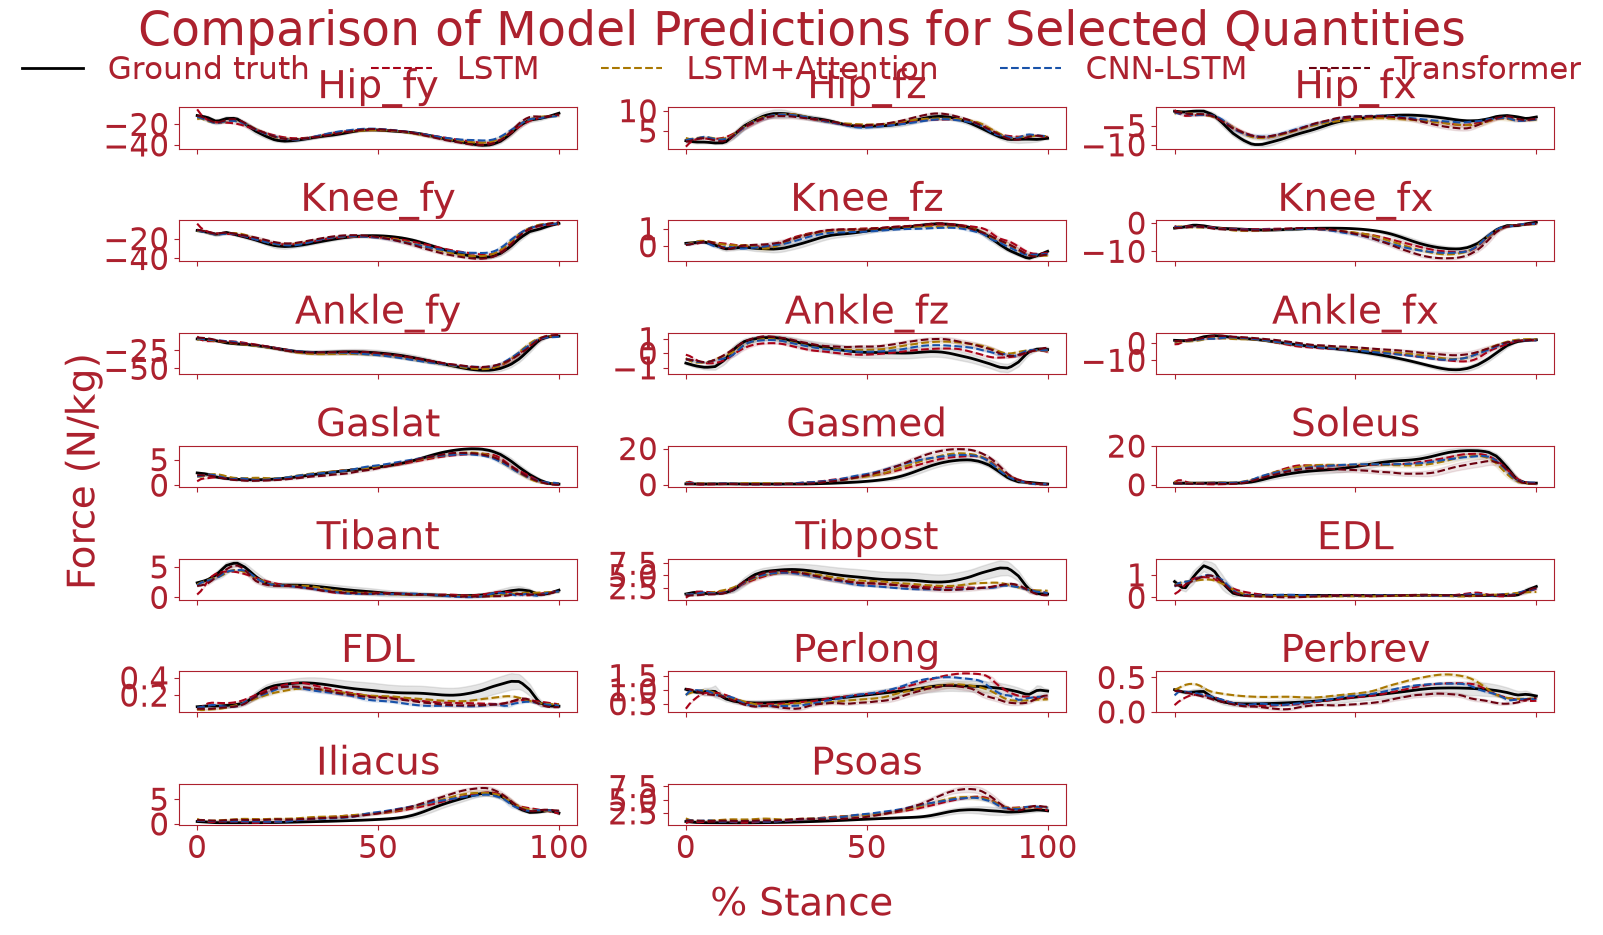

In [9]:
MODEL_COLORS = ['#A90218', '#A97802', '#1852A9', '#6B0110']
# crimson, amber, steel blue, maroon

# ── Figure size config (mm) ───────────────────────────────────────────────────
FIG_W_MM     = 390
SUBPLOT_H_MM = 210
LEGEND_H_MM  =  25

perc_stance = np.linspace(0, 100, SEQ_LEN)
true_mean   = y_eval.mean(axis=0)
true_std    = y_eval.std(axis=0)

pred_means = {n: p.mean(axis=0) for n, p in preds_eval.items()}
pred_stds  = {n: p.std(axis=0)  for n, p in preds_eval.items()}

ncols = 3
nrows = math.ceil(N_EVAL / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=mm(FIG_W_MM, SUBPLOT_H_MM + LEGEND_H_MM),
                         sharex=True)
axes = axes.flatten()

for i, lbl in enumerate(_eval_labels):
    ax = axes[i]
    ax.plot(perc_stance, true_mean[:, i], color='black', linewidth=2, label='Ground truth')
    ax.fill_between(perc_stance,
                    true_mean[:, i] - true_std[:, i],
                    true_mean[:, i] + true_std[:, i],
                    color='gray', alpha=0.2)
    for model_name, label, color in zip(MODELS_TO_COMPARE, MODEL_LABELS, MODEL_COLORS):
        if model_name not in pred_means:
            continue
        ax.plot(perc_stance, pred_means[model_name][:, i],
                color=color, linewidth=1.5, linestyle='--', label=label)
        ax.fill_between(perc_stance,
                        pred_means[model_name][:, i] - pred_stds[model_name][:, i],
                        pred_means[model_name][:, i] + pred_stds[model_name][:, i],
                        color=color, alpha=0.1)
    if lbl in ('ehl', 'edl', 'fdl', 'fhl'):
        lbl_string = lbl.upper()
    else:
        lbl_string = lbl.capitalize()
    ax.set_title(lbl_string, fontsize=FONT['title'])
    ax.tick_params()

for j in range(N_EVAL, len(axes)):
    axes[j].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc='upper center',
           bbox_to_anchor=(0.5, 0.98),
           ncol=len(MODELS_TO_COMPARE) + 1,
           fontsize=FONT['legend'],
           frameon=False)

fig.suptitle('Comparison of Model Predictions for Selected Quantities',
             fontsize=FONT['suptitle'], y=1.0)
fig.supxlabel('% Stance', fontsize=FONT['axis_label'])
fig.supylabel('Force (N/kg)', fontsize=FONT['axis_label'])

top = 1 - LEGEND_H_MM / (SUBPLOT_H_MM + LEGEND_H_MM)
plt.tight_layout()
plt.subplots_adjust(top=top)
plt.savefig('mean_prediction_comparison.svg', format='svg', bbox_inches='tight')
plt.show()

## Visualization — individual mean ± SD plots (one per output)

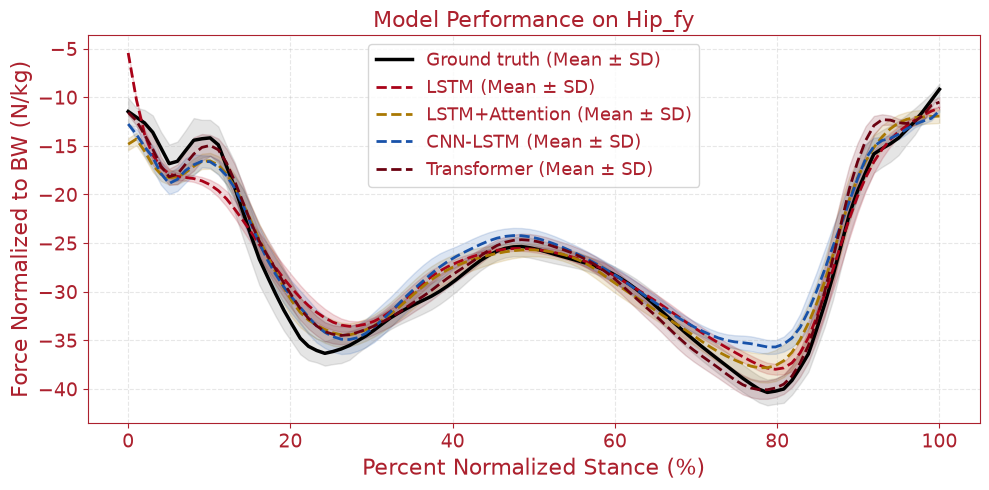

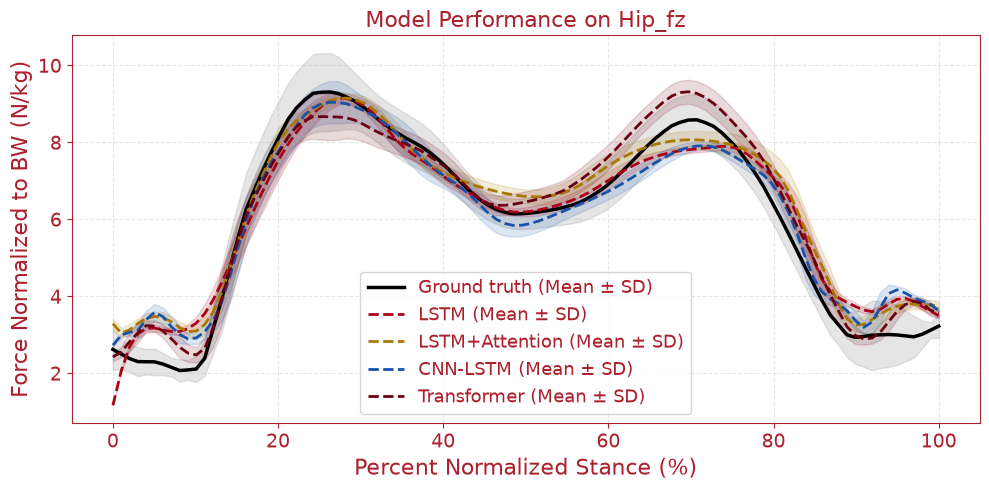

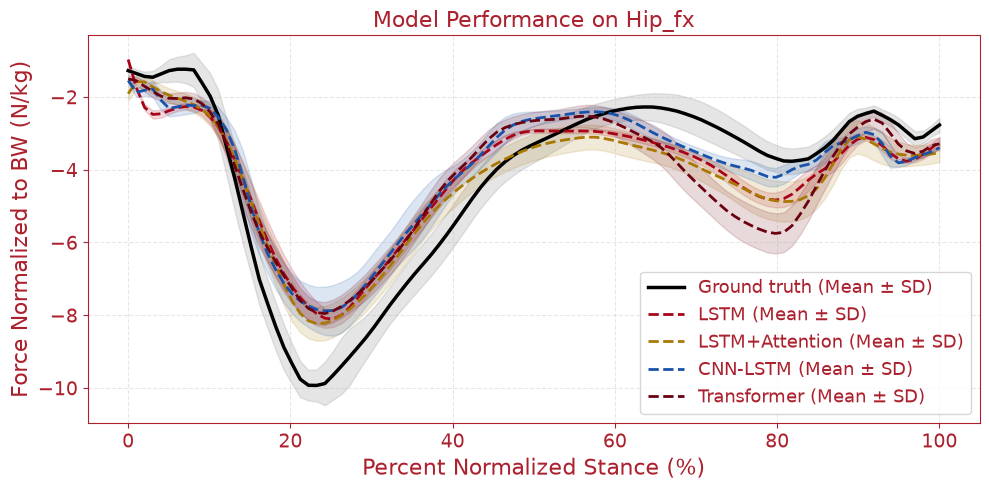

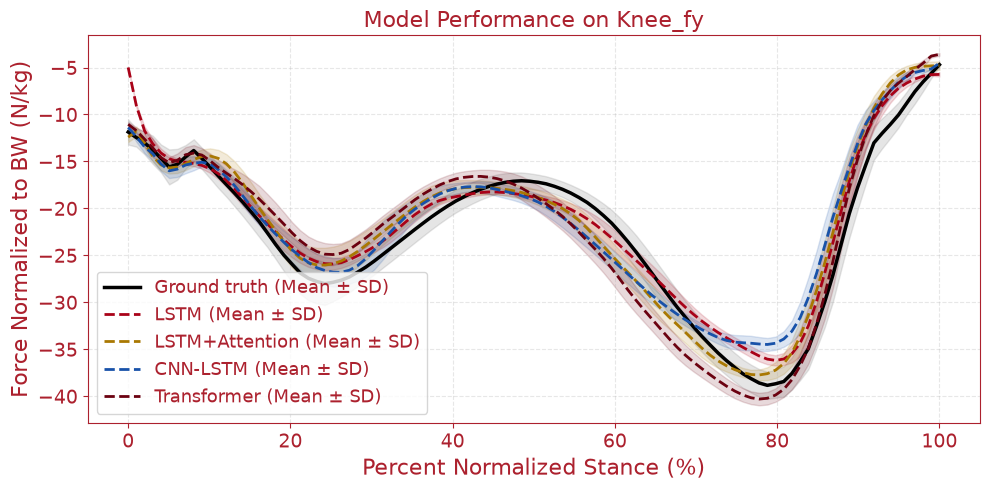

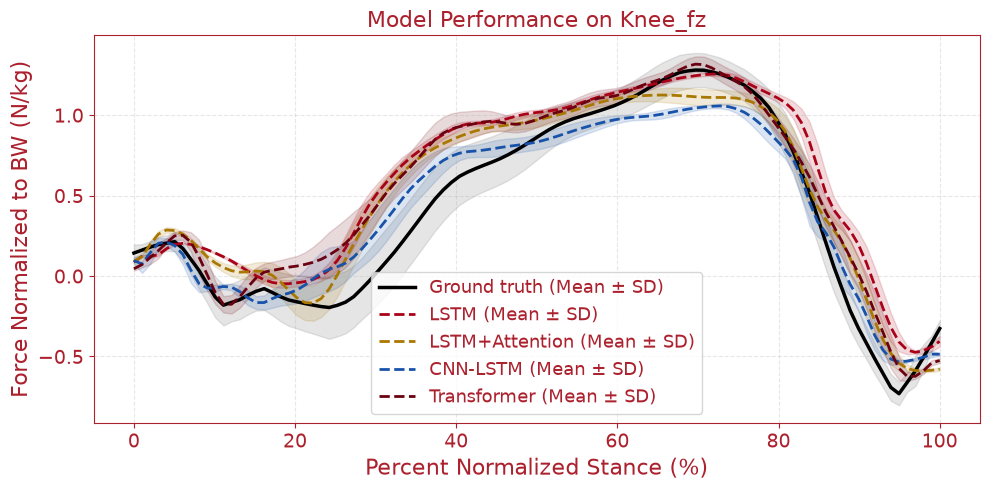

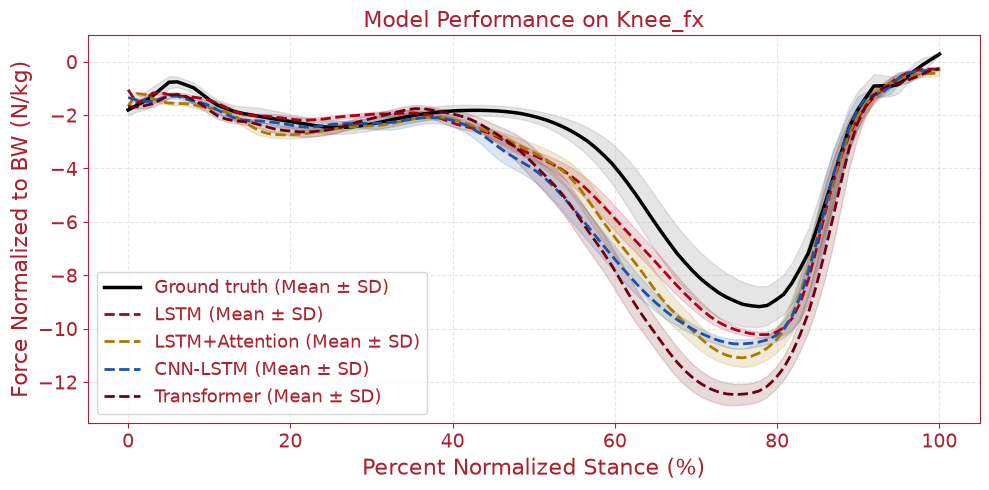

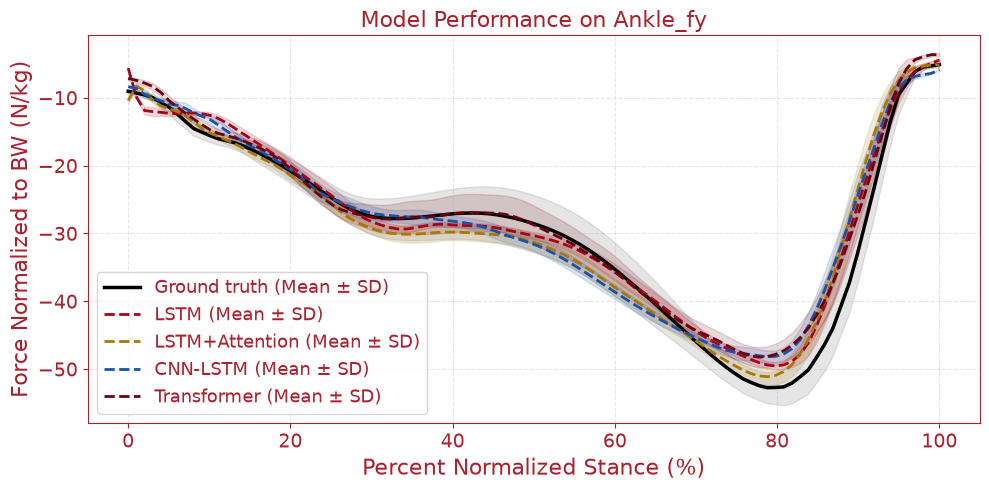

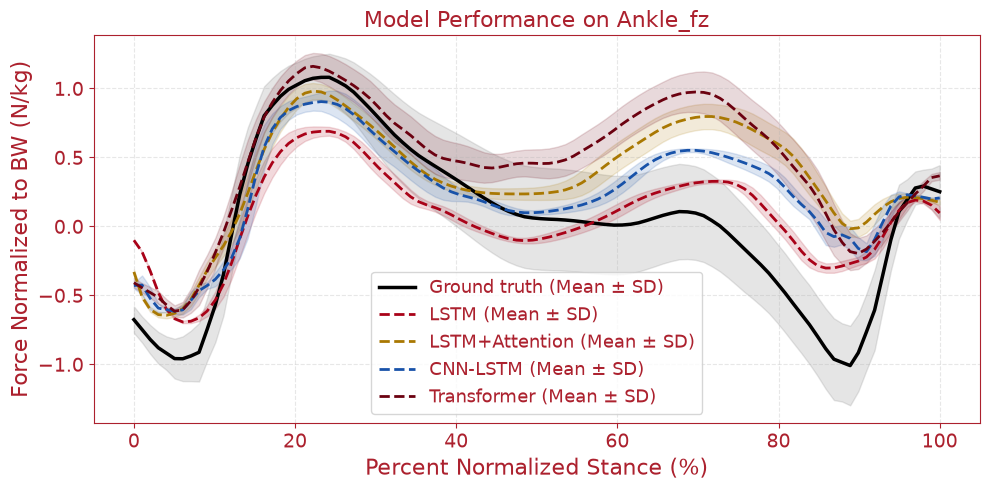

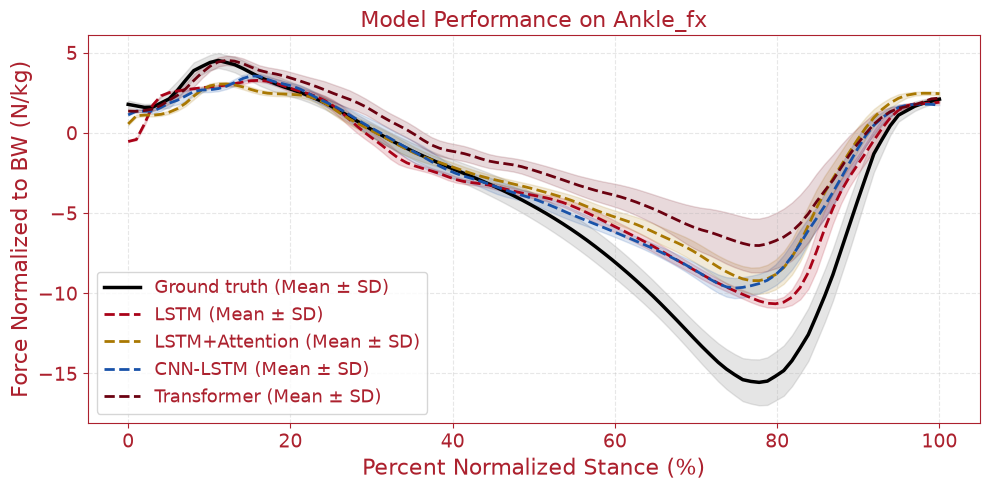

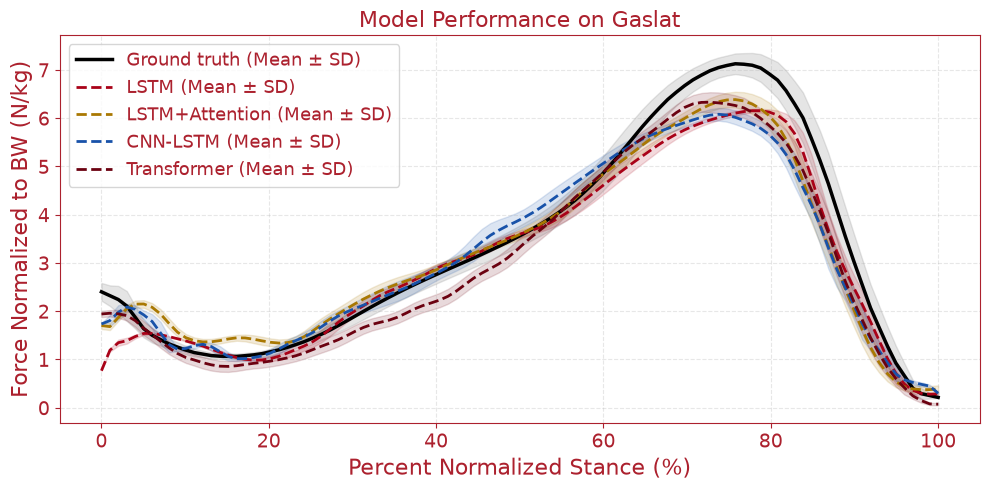

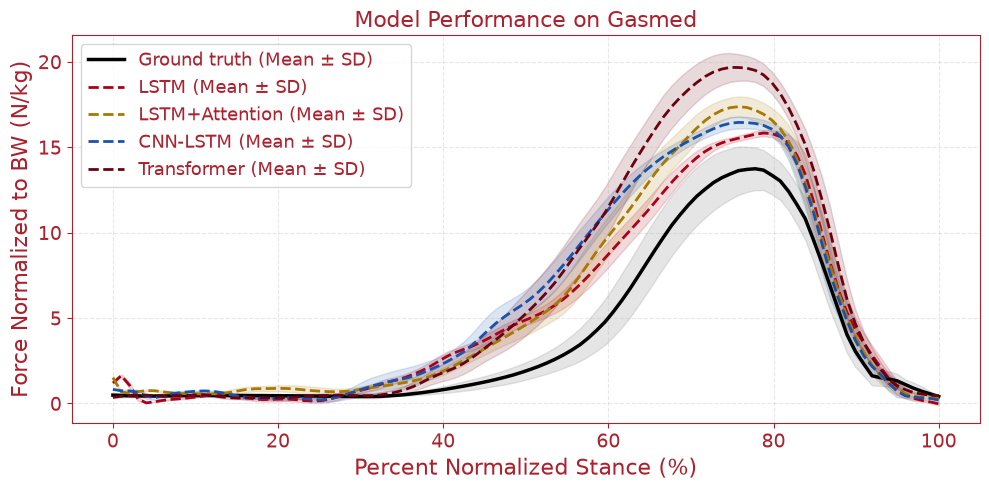

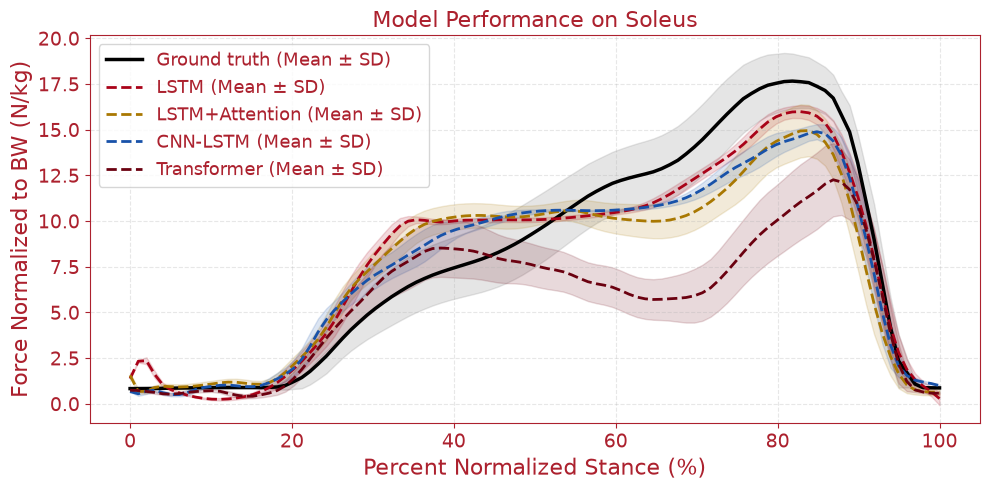

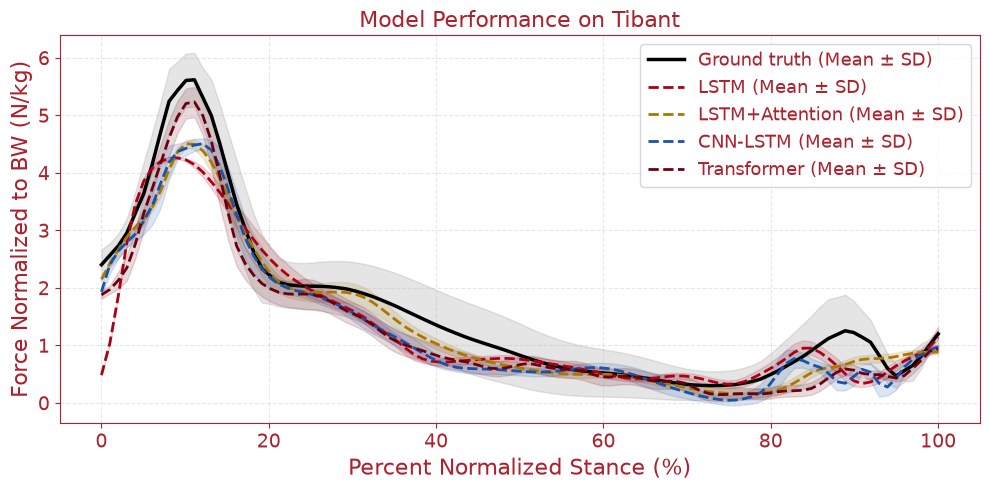

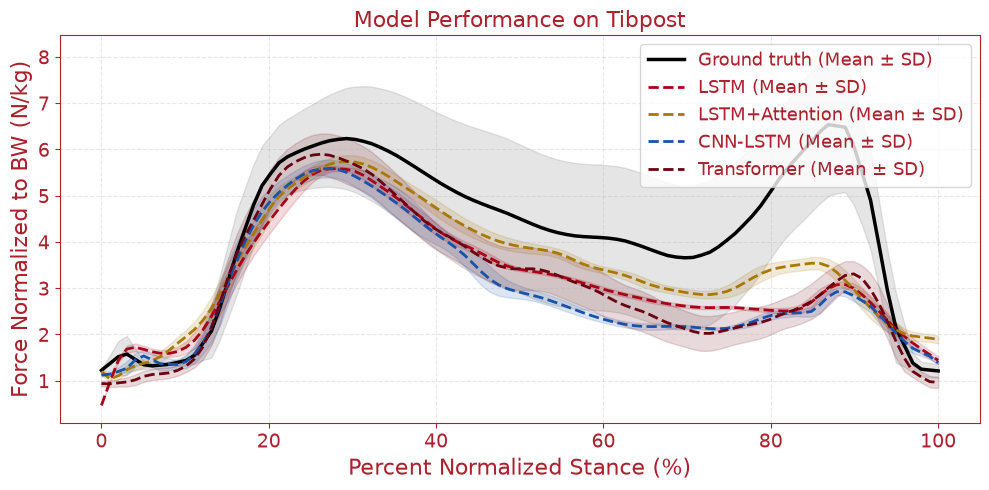

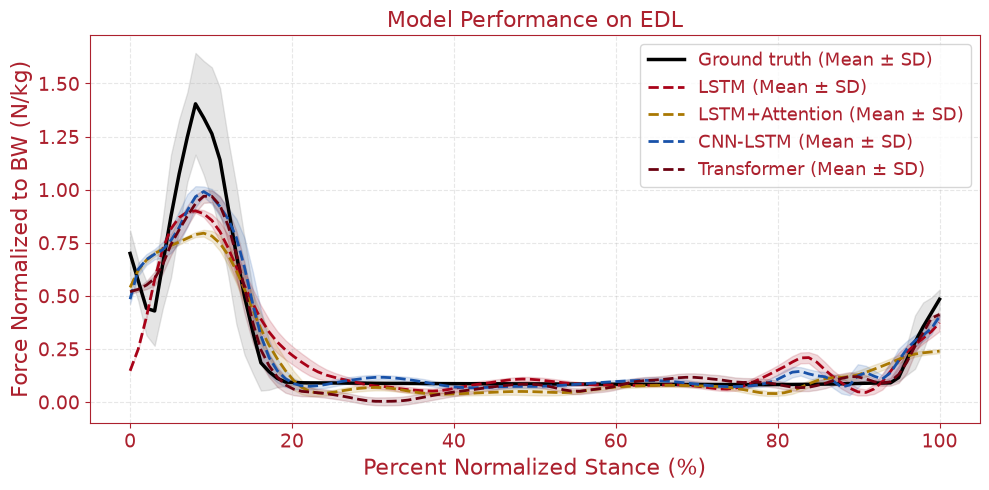

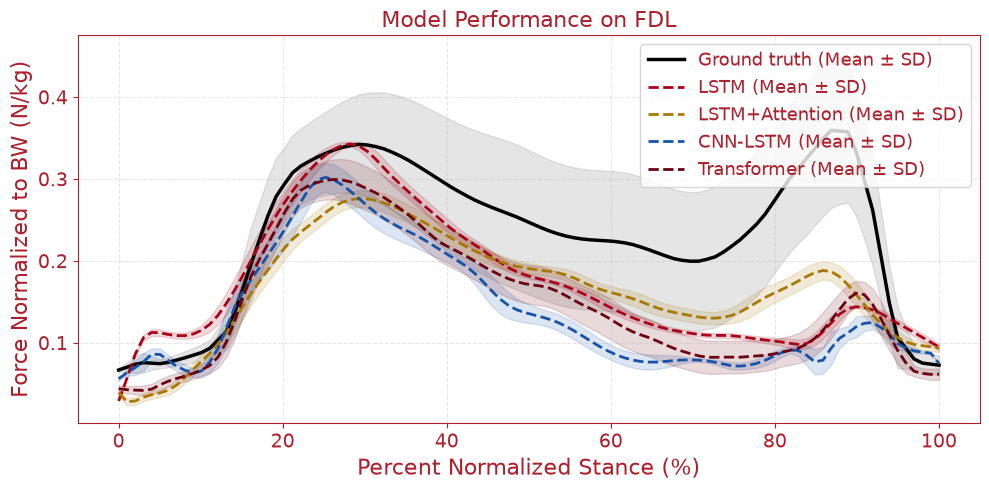

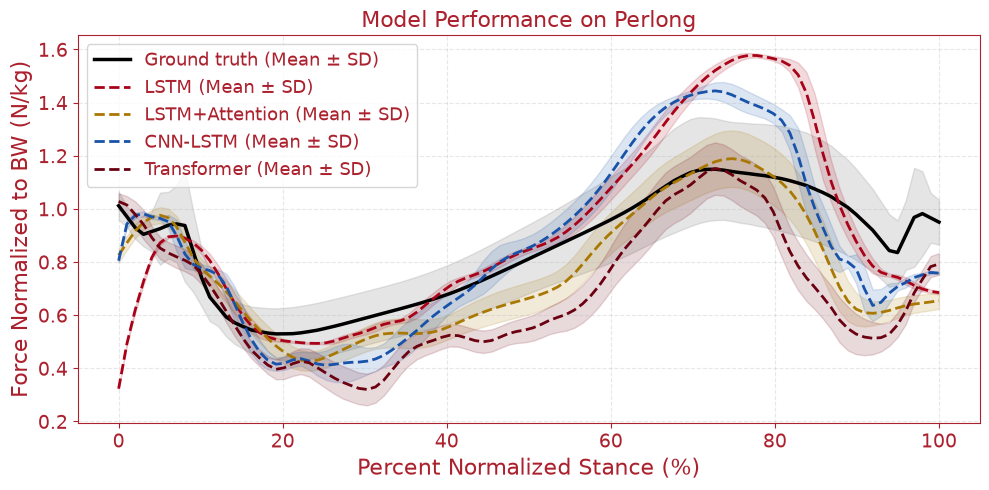

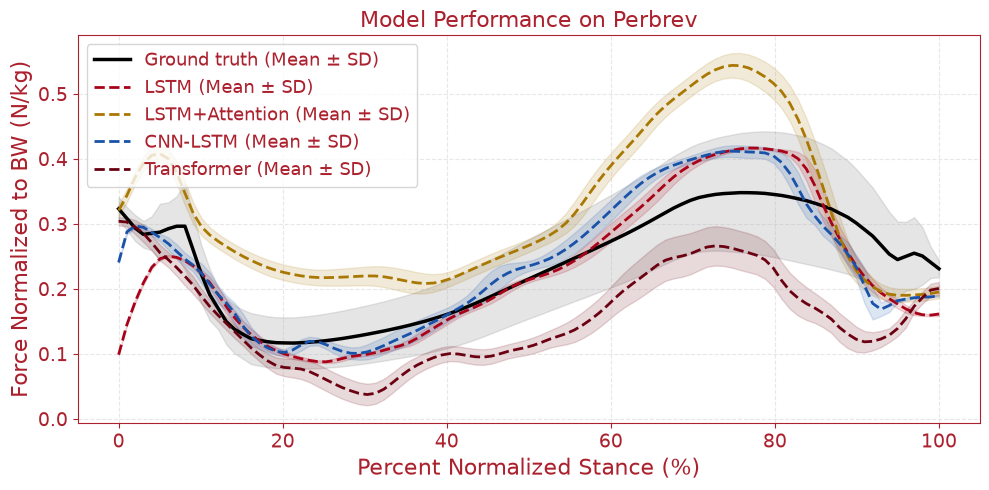

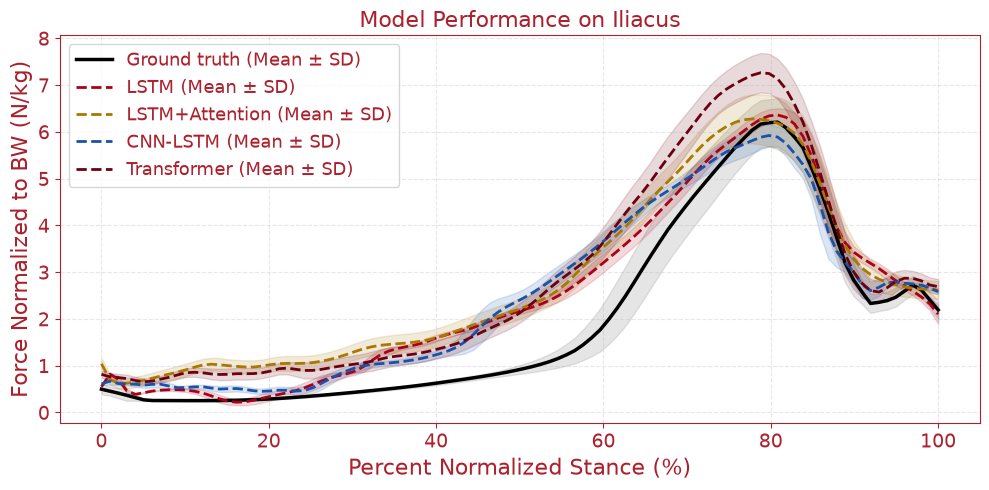

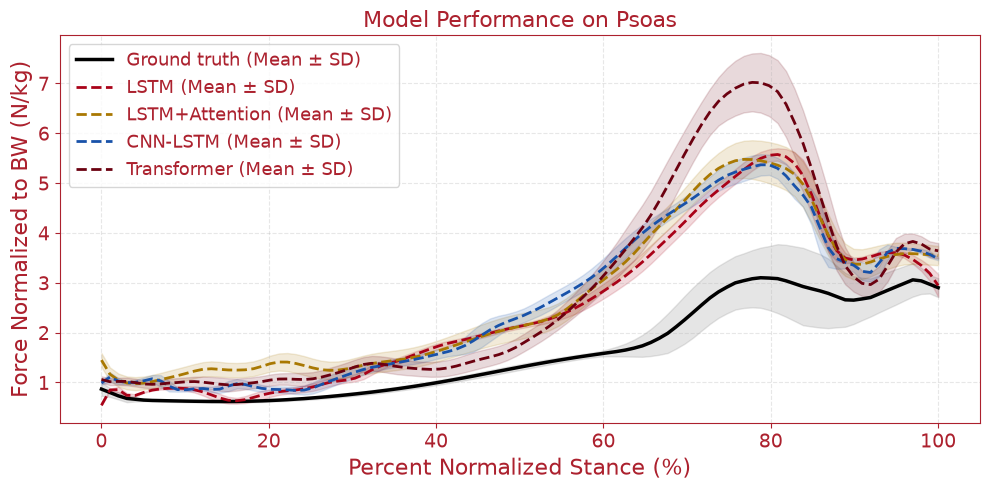

In [10]:
for i, lbl in enumerate(_eval_labels):
    true_m = y_eval[:, :, i].mean(axis=0)
    true_s = y_eval[:, :, i].std(axis=0)

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(perc_stance, true_m, color='black', linewidth=2.5, label='Ground truth (Mean ± SD)')
    ax.fill_between(perc_stance, true_m - true_s, true_m + true_s, color='gray', alpha=0.2)

    for model_name, label, color in zip(MODELS_TO_COMPARE, MODEL_LABELS, MODEL_COLORS):
        if model_name not in preds_eval:
            continue
        pred_m = preds_eval[model_name][:, :, i].mean(axis=0)
        pred_s = preds_eval[model_name][:, :, i].std(axis=0)
        ax.plot(perc_stance, pred_m, color=color, linewidth=2, linestyle='--',
                label=f'{label} (Mean ± SD)')
        ax.fill_between(perc_stance, pred_m - pred_s, pred_m + pred_s, color=color, alpha=0.15)
    if lbl == 'ehl' or lbl == 'edl' or lbl == 'fdl' or lbl == 'fhl':
        lbl_string = str(lbl).upper()   
    else:
        lbl_string = str(lbl).capitalize()
    ax.set_title(f'Model Performance on {lbl_string}', fontsize=16)
    ax.set_xlabel('Percent Normalized Stance (%)', fontsize=16)
    ax.set_ylabel('Force Normalized to BW (N/kg)', fontsize=16)
    ax.legend(fontsize=13)
    ax.tick_params(labelsize=14)
    ax.grid(linestyle='--', alpha=0.3)
    plt.tight_layout()
    #plt.savefig(f'{lbl}.svg', format='svg')
    plt.show()

## Visualization — single test sample (SAMPLE_IDX)

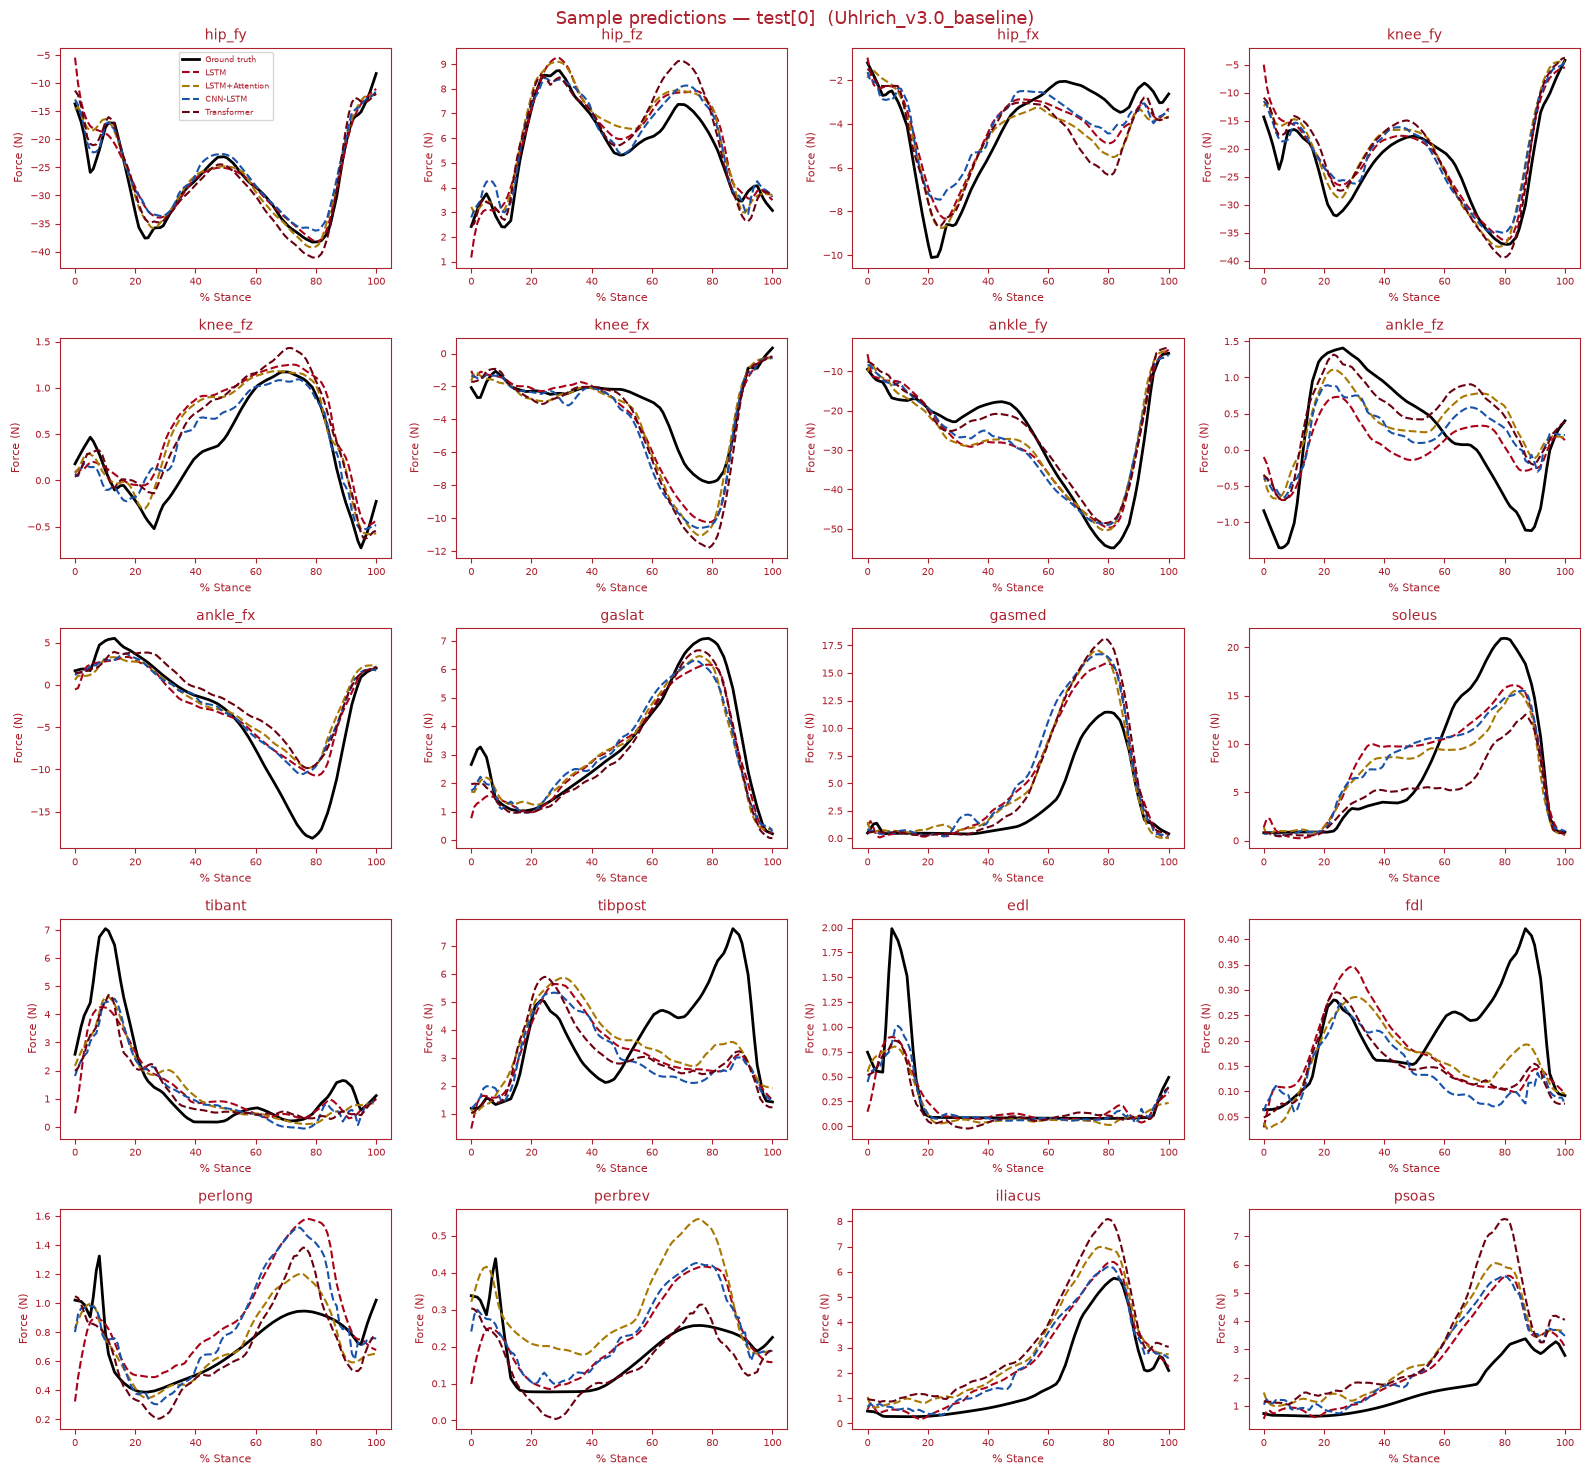

In [11]:
true_sample = y_eval[SAMPLE_IDX]   # (seq_len, N_EVAL)

ncols = 4
nrows = math.ceil(N_EVAL / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axes = axes.flatten()

for i, lbl in enumerate(_eval_labels):
    ax = axes[i]
    ax.plot(perc_stance, true_sample[:, i], color='black', linewidth=2, label='Ground truth')
    for model_name, label, color in zip(MODELS_TO_COMPARE, MODEL_LABELS, MODEL_COLORS):
        if model_name not in preds_eval:
            continue
        ax.plot(perc_stance, preds_eval[model_name][SAMPLE_IDX, :, i],
                color=color, linewidth=1.5, linestyle='--', label=label)
    ax.set_title(lbl, fontsize=10)
    ax.set_xlabel('% Stance', fontsize=8)
    ax.set_ylabel('Force (N)', fontsize=8)
    ax.tick_params(labelsize=7)
    if i == 0:
        ax.legend(fontsize=6)

for j in range(N_EVAL, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Sample predictions — test[{SAMPLE_IDX}]  ({test_prefix})', fontsize=13)
plt.tight_layout()
plt.show()

## Bar charts — per-output metrics (Figure B)

Model             knee_fy (MAE/thr)  ankle_fy (MAE/thr)
lstm                        0.40            0.64
lstm_attn                   0.47            0.66
cnn_lstm                    0.52            0.71
transformer                 0.56            0.56


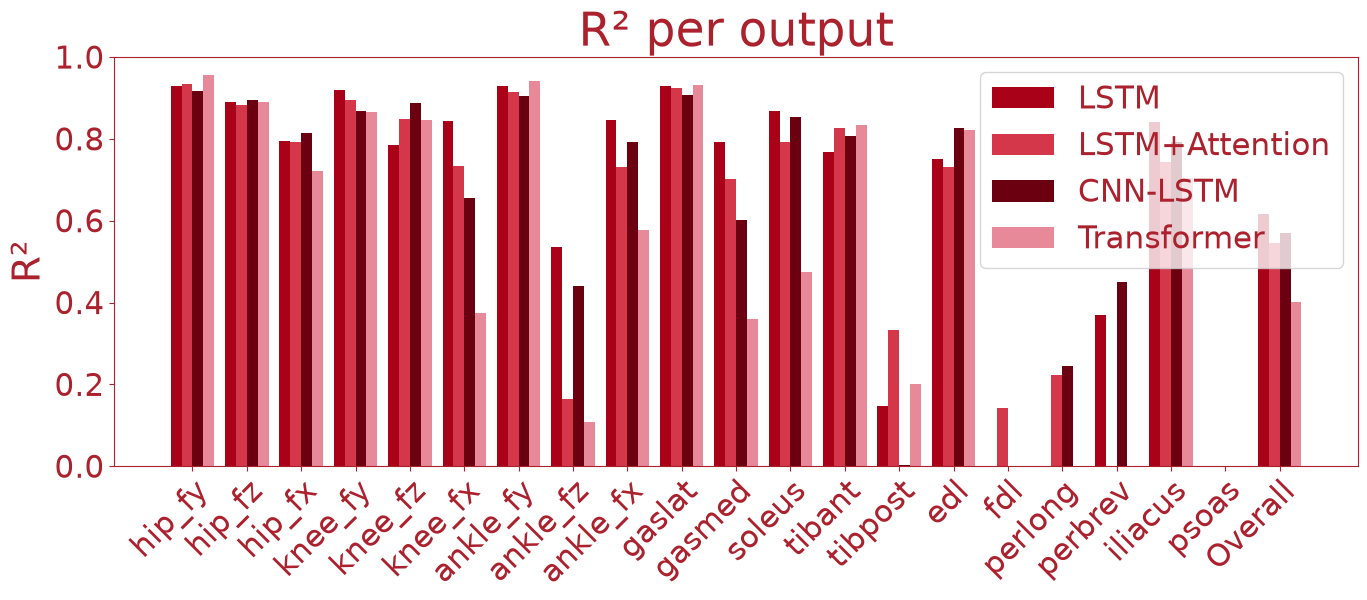

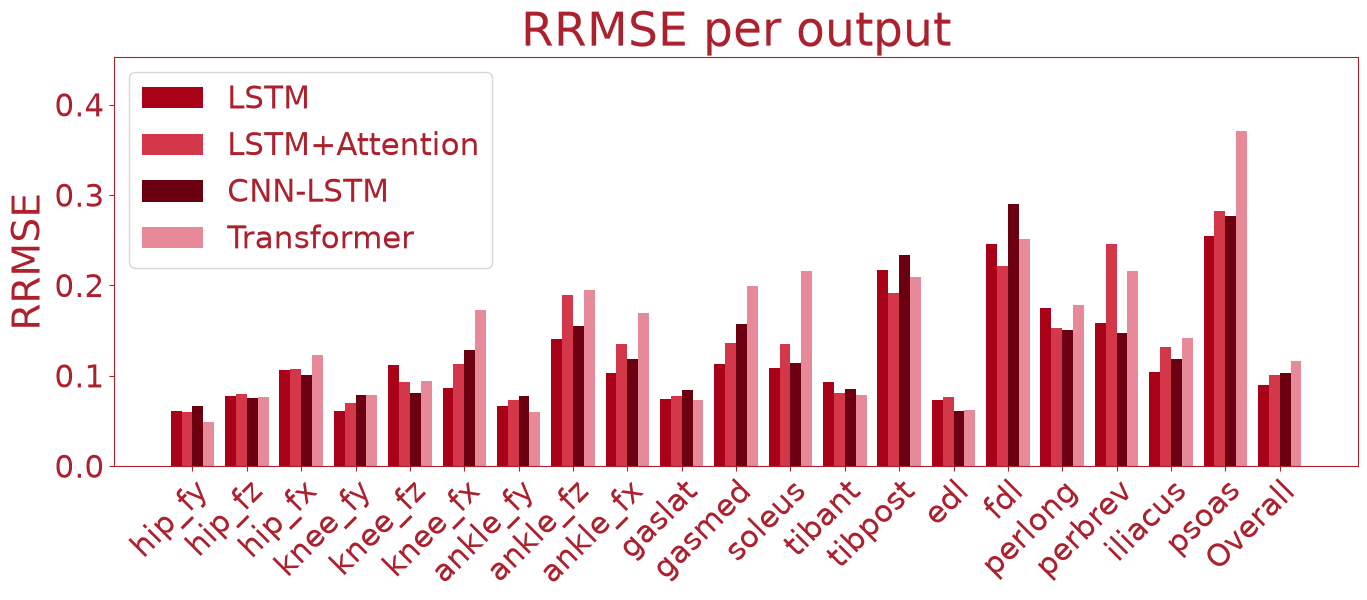

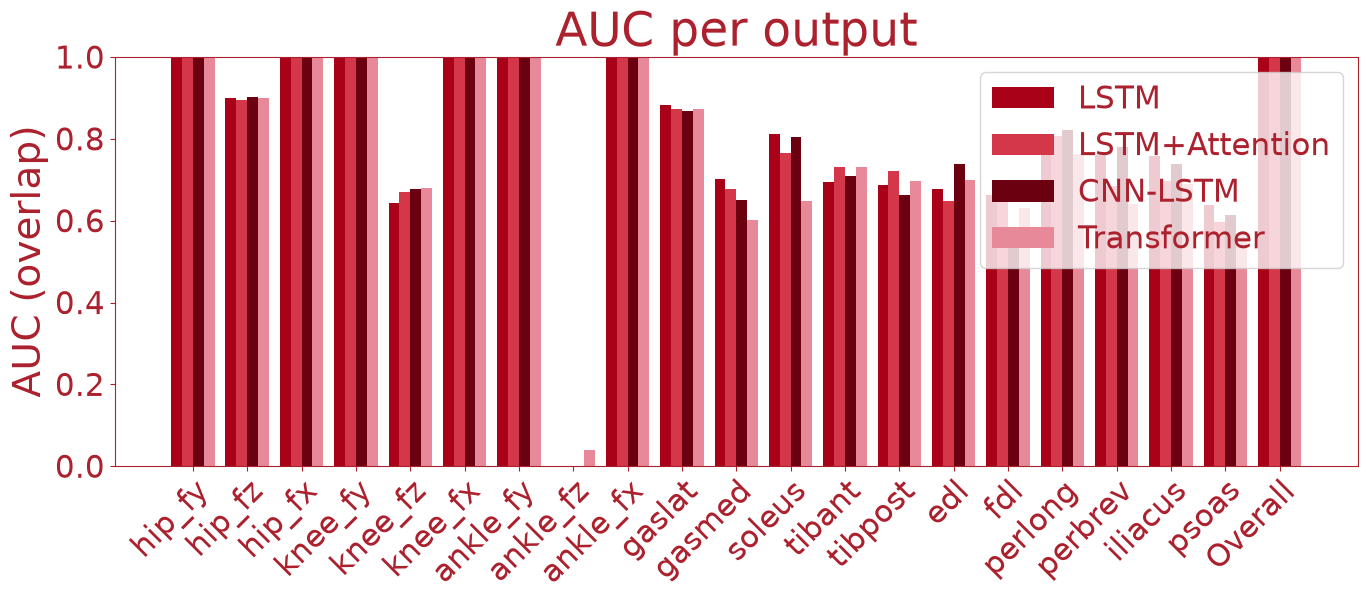

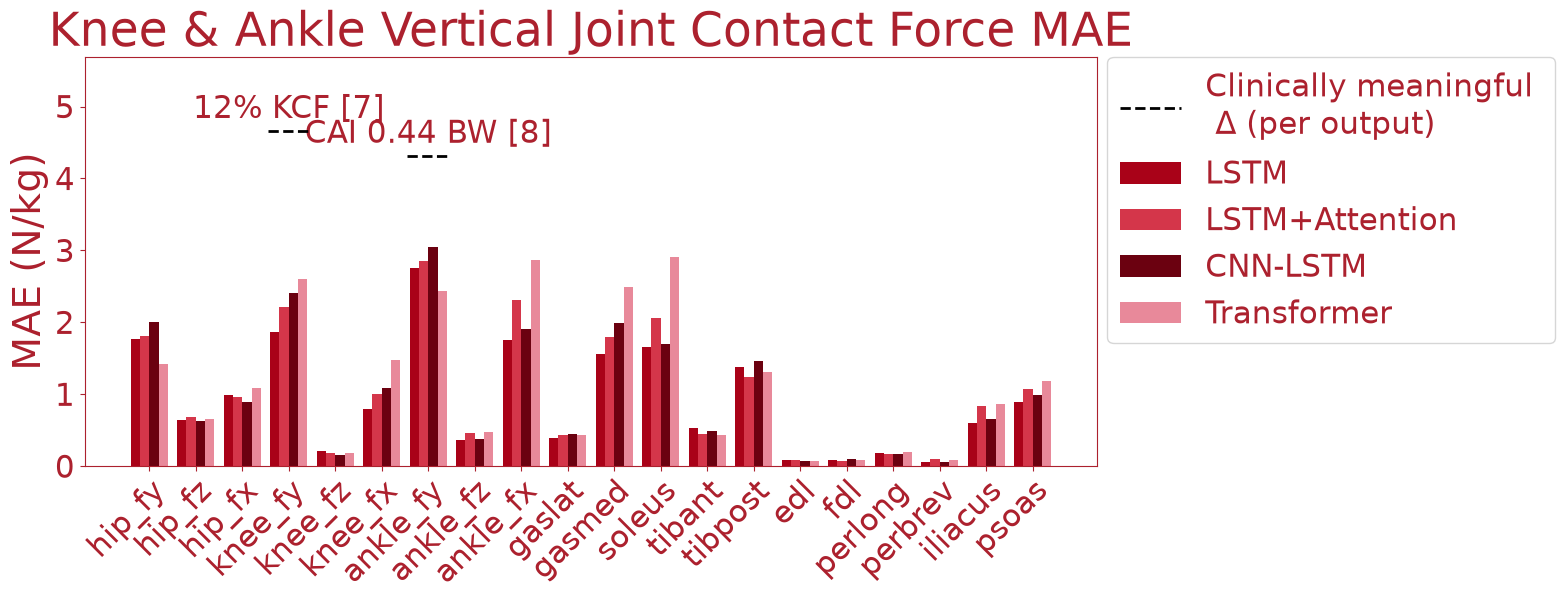

In [12]:
CLINICAL_THRESHOLDS = {
    'knee_fy':  dict(frac=0.12, src='12% KCF [7]'),          # relative to peak GT
    'ankle_fy': dict(delta_bw=0.44, src='CAI 0.44 BW [8]'),  # absolute (BW*g)
}

def _gt_peak(y, key):
    """Peak magnitude (N/kg) of the mean ground-truth curve for `key`."""
    return float(np.abs(y[:, :, OUTPUT_KEYS.index(key)].mean(axis=0)).max())


def _clinical_check(y, preds):
    """JCF clinical-threshold check -- ported to CrossVal.ipynb's transfer-cell
    helpers verbatim (see that notebook's "Helpers: prediction, reconstruction
    metrics, JCF clinical check" cell); keep both copies identical. Only
    knee_fy/ankle_fy have published thresholds, intentionally scoped to just
    those two vertical JCF components."""
    out = {}
    for key, spec in CLINICAL_THRESHOLDS.items():
        if key not in OUTPUT_KEYS:
            continue
        idx = OUTPUT_KEYS.index(key)
        mae_key = float(np.mean(np.abs(y[:, :, idx] - preds[:, :, idx])))
        threshold = spec['frac'] * _gt_peak(y, key) if 'frac' in spec else spec['delta_bw'] * 9.81
        out[key] = dict(mae=mae_key, threshold=float(threshold),
                        mae_over_threshold=float(mae_key / threshold) if threshold else float('nan'))
    return out


for model_name, r in test_results.items():
    overall[model_name]['jcf_clinical'] = _clinical_check(y_test, r['preds'])

print(f'{"Model":<16}  ' + '  '.join(f'{k} (MAE/thr)' for k in CLINICAL_THRESHOLDS))
for model_name in MODELS_TO_COMPARE:
    if model_name not in overall:
        continue
    jc = overall[model_name]['jcf_clinical']
    row = '  '.join(f'{jc[k]["mae_over_threshold"]:>14.2f}' for k in CLINICAL_THRESHOLDS if k in jc)
    print(f'{model_name:<16}  {row}')

MODEL_COLORS = ['#A90218', '#D4364A', '#6B0110', '#E8899A']
# dark crimson → mid red → maroon → dusty pink
def _bar_chart(metric_key, ylabel, title, ylim=None,
               per_output_thresholds=None, show_overall=True, save_path=None):
    models_present = [n for n in MODELS_TO_COMPARE if n in per_output]
    labels_present = [MODEL_LABELS[MODELS_TO_COMPARE.index(n)] for n in models_present]
    colors_present = [MODEL_COLORS[MODELS_TO_COMPARE.index(n)] for n in models_present]

    # per_output[*][metric_key] holds all-output arrays (N_OUTPUTS) for
    # rrmse/mae/r2/auc, but dice is computed subset-only (N_EVAL) -- see the
    # Dice section below. Slice down to the reporting subset only when needed.
    def _subset(arr):
        return np.asarray(arr)[_eval_idxs] if len(arr) == N_OUTPUTS else np.asarray(arr)

    vals_per_out = np.array([_subset(per_output[n][metric_key]) for n in models_present])
    if metric_key == 'rrmse':
        vals_overall = np.array([overall[n]['subset_rrmse_w'] for n in models_present])
    elif metric_key == 'mae':
        vals_overall = np.array([overall[n]['mae'] for n in models_present])
    elif metric_key == 'dice':
        vals_overall = np.array([overall[n]['dice_mean'] for n in models_present])
    elif metric_key == 'auc':
        vals_overall = np.array([overall[n]['subset_auc'] for n in models_present])
    else:
        vals_overall = np.array([overall[n]['subset_r2'] for n in models_present])

    if show_overall:
        all_vals = np.hstack([vals_per_out, vals_overall.reshape(-1, 1)])
    else:
        all_vals = vals_per_out

    if not np.all(np.isfinite(all_vals)):
        print(f"  WARNING: {metric_key} has {int(np.sum(~np.isfinite(all_vals)))} "
              f"non-finite value(s) -> those bars won't render (check model training/eval)")

    n_groups = N_EVAL + (1 if show_overall else 0)
    x       = np.arange(n_groups)
    bar_w   = 0.8 / len(models_present)
    offsets = np.arange(len(models_present)) * bar_w - (len(models_present) - 1) * bar_w / 2

    fig, ax = plt.subplots(figsize=mm(350, 155))
    for label, color, offset, row in zip(labels_present, colors_present, offsets, all_vals):
        ax.bar(x + offset, row, width=bar_w, label=label, color=color)

    # per-output clinical lines: one segment per output, each at its own height
    thr_tops = []
    if per_output_thresholds:
        drew = False
        for i, lab in enumerate(_eval_labels):
            if lab in per_output_thresholds:
                spec = per_output_thresholds[lab]
                try:
                    thr = spec['delta_bw'] * 9.81 if 'delta_bw' in spec else spec['frac'] * _gt_peak(y_test, lab)
                except Exception as e:
                    print(f'  clinical line for {lab} skipped: {e}')
                    continue
                if not np.isfinite(thr):
                    continue
                thr_tops.append(thr)
                ax.plot([i - 0.45, i + 0.45], [thr, thr], color='black', lw=2, ls='--', zorder=5)
                ax.annotate(spec['src'], (i, thr), textcoords='offset points', xytext=(0, 4),
                            ha='center', va='bottom', fontsize=FONT['tick'])
                drew = True
        if drew:
            ax.plot([], [], color='black', lw=2, ls='--', label='Clinically meaningful \n Δ (per output)')

    xlabels = list(_eval_labels) + (['Overall'] if show_overall else [])
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, rotation=45, ha='right', rotation_mode='anchor', fontsize=FONT['tick'])
    ax.set_ylabel(ylabel, fontsize=FONT['axis_label'])
    ax.set_title(title, fontsize=FONT['suptitle'])

    # y-limits: honour `ylim` if given, else auto-fit FINITE bars + clinical lines
    finite   = all_vals[np.isfinite(all_vals)]
    data_top = finite.max() if finite.size else 1.0
    data_bot = min(0.0, finite.min()) if finite.size else 0.0
    top      = max([data_top] + thr_tops)
    if ylim and ylim[1] is not None:
        ax.set_ylim(ylim[0] if ylim[0] is not None else 0, ylim[1])
    else:
        ax.set_ylim(data_bot, top * 1.22)

    if not show_overall:
        ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
        plt.tight_layout()
        plt.subplots_adjust(right=0.80)
    else:
        ax.legend(loc='best', fontsize=FONT['legend'])
        plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, format='svg')
    plt.show()


_bar_chart('r2',    'R²',    'R² per output', ylim=(None, 1.0))
_bar_chart('rrmse', 'RRMSE', 'RRMSE per output')
_bar_chart('auc',   'AUC (overlap)', 'AUC per output', ylim=(None, 1.0))
_bar_chart('mae',   'MAE (N/kg)',
           'Knee & Ankle Vertical Joint Contact Force MAE',
           per_output_thresholds=CLINICAL_THRESHOLDS,
           show_overall=False,
           save_path=f'{model_prefix}_mae_jcf.svg')

## Waveform similarity (Dice) & statistical comparison

Model              Dice (mean)
lstm                    0.7648
lstm_attn               0.8759
cnn_lstm                0.8649
transformer             0.8895


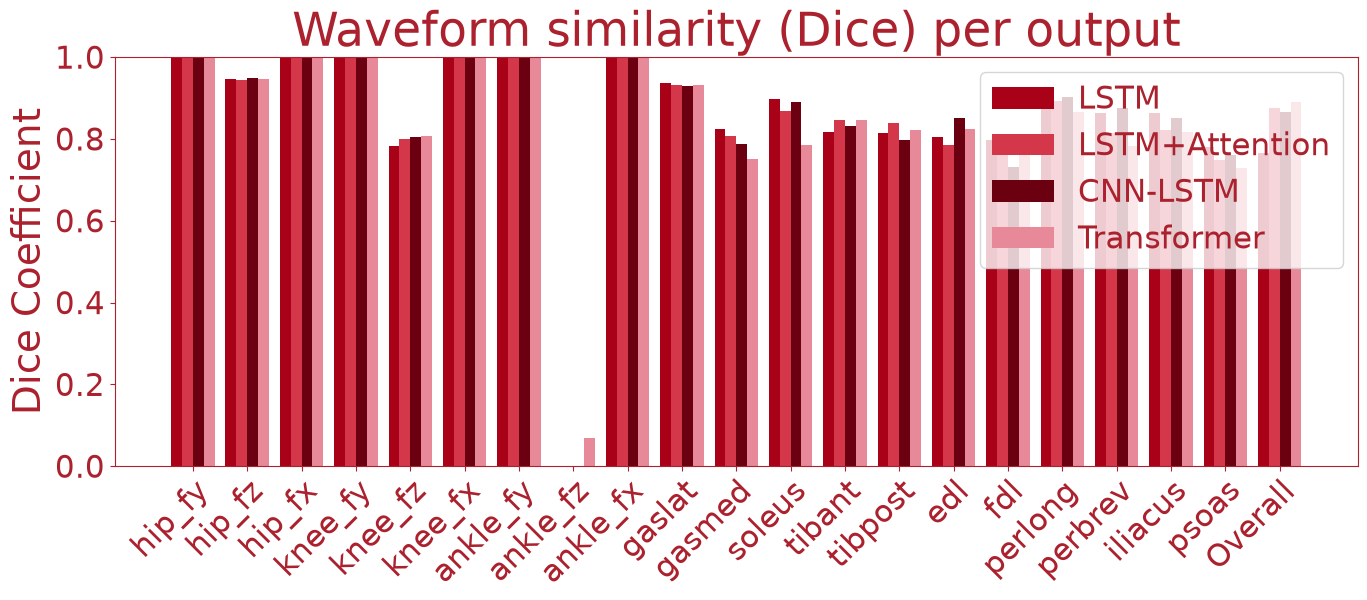


Model A           Model B            Dice p-value   AUC p-value
LSTM              LSTM+Attention           0.0484        0.0000
LSTM              CNN-LSTM                 0.0000        0.0000
LSTM              Transformer              0.0447        0.0000
LSTM+Attention    CNN-LSTM                 0.0001        0.0000
LSTM+Attention    Transformer              0.0000        0.0000
CNN-LSTM          Transformer              0.0000        0.0000


In [13]:
from itertools import combinations

# ── Dice coefficient per output (subset) ──────────────────────────────────────
for model_name, pred in preds_eval.items():
    dice = calc_dice_per_output(y_eval, pred, labels=_eval_labels, verbose=False)
    per_output[model_name]['dice'] = dice
    overall[model_name]['dice_mean'] = float(dice.mean())

print(f'{"Model":<16}  {"Dice (mean)":>12}')
for model_name in MODELS_TO_COMPARE:
    if model_name not in overall:
        continue
    print(f'{model_name:<16}  {overall[model_name]["dice_mean"]:>12.4f}')

_bar_chart('dice', 'Dice Coefficient', 'Waveform similarity (Dice) per output', ylim=(None, 1.0))

# ── Pairwise statistical comparison (Wilcoxon signed-rank) ────────────────────
# Answers "does model A differ significantly from model B", not just "is the
# number bigger" -- compares per-trial Dice and per-trial AUC (both averaged
# over SUBSET_KEYS) between every pair of models. config.yaml's
# reporting.comparison_metrics = [auc, dice].
dice_per_trial = {
    model_name: calc_dice_per_trial(y_eval, pred).mean(axis=1)   # (n_samples,)
    for model_name, pred in preds_eval.items()
}
auc_per_trial = {
    model_name: calc_auc_per_trial(y_eval, pred).mean(axis=1)    # (n_samples,)
    for model_name, pred in preds_eval.items()
}

model_names_present = [n for n in MODELS_TO_COMPARE if n in test_results]

print(f'\n{"Model A":<16}  {"Model B":<16}  {"Dice p-value":>13}  {"AUC p-value":>12}')
for m1, m2 in combinations(model_names_present, 2):
    dice_stat = compare_models_wilcoxon(dice_per_trial[m1], dice_per_trial[m2])
    auc_stat  = compare_models_wilcoxon(auc_per_trial[m1], auc_per_trial[m2])
    l1 = MODEL_LABELS[MODELS_TO_COMPARE.index(m1)]
    l2 = MODEL_LABELS[MODELS_TO_COMPARE.index(m2)]
    print(f'{l1:<16}  {l2:<16}  {dice_stat["p_value"]:>13.4f}  {auc_stat["p_value"]:>12.4f}')

## Trial-phase stratified comparison (baseline vs. retention)

Requires a v3+ test file (`trial_names`/`subject_ids` present). Grounded in
**Uhlrich et al. 2022 (Sci Rep)**, "Muscle coordination retraining inspired by
musculoskeletal simulations reduces knee contact force" — the paper's headline
result is a **baseline vs. retention** comparison: participants retained a
25±15% reduction in gastrocnemius:soleus activation ratio (p=0.004) and a
17±19% reduction in gastrocnemius activation (p=0.033), with ankle
plantarflexion moment essentially unchanged (3±14%, p=0.063) — i.e. the total
plantarflexor output stayed the same, only the internal gastroc/soleus split
moved. `calc_gastroc_soleus_ratio` (`eval_utils.py`) is a force-based proxy for
that same ratio (the paper measured EMG activation, this model predicts
force). Its default `gastroc_keys=('gasmed',)` is medial gastrocnemius ALONE,
matching Eq. 3's actual muscle scope per the paper's Methods (not
medial+lateral combined) — consistent with the ground-truth reproduction in
`Gastroc_Soleus_Activation_Ratio.ipynb` and the cross-stratum transfer metric
in `CrossVal.ipynb`.

Two complementary questions:
- **Mode A**: does the pooled model's *own predictions* reproduce that shift
  when split by trial phase, without the model ever being told which trial is
  which? Also checks whether our own ground-truth (SO-derived) data reproduces
  the paper's reported direction/magnitude at all, as a sanity check on the
  pipeline before trusting any model comparison built on top of it.
- **Mode B**: does a specialist model *fine-tuned* on one stratum
  (`Tune_Models.ipynb`'s `FINETUNE_MODE`) actually do better than the pooled
  generalist on that same stratum's held-out test segments?

In [14]:
STRATA = {
    'baseline':  ['walking_baseline1'],
    'retention': ['walking_retention1'],
}

# Reported by Uhlrich et al. 2022 (Sci Rep): 25±15% reduction in gastroc:soleus
# activation ratio at retention vs. baseline (p=0.004). We're comparing against
# a force-based proxy of the same ratio (calc_gastroc_soleus_ratio's docstring;
# medial gastrocnemius alone by default, matching Eq. 3's muscle scope), so
# treat this as a check on direction/magnitude, not an exact numeric match
# (EMG activation vs. predicted force).
PAPER_RETENTION_RATIO_REDUCTION_PCT = 25.0

if not HAS_STRATIFICATION_METADATA:
    print('Skipping stratified comparison -- this test file has no trial_names/'
          'subject_ids (only available for v3+ datasets).')
else:
    gastroc_soleus_true = calc_gastroc_soleus_ratio(y_test, OUTPUT_KEYS)
    gastroc_soleus_pred = {
        model_name: calc_gastroc_soleus_ratio(r['preds'], OUTPUT_KEYS)
        for model_name, r in test_results.items()
    }

    print('=== Mode A: pooled model, evaluated separately per stratum ===')
    print('(does the pooled model reproduce the baseline vs. retention shift on its own?)\n')

    stratum_means_true = {}
    for stratum_name, trial_values in STRATA.items():
        stratum_mask = np.isin(trial_names_test, trial_values)
        n = int(stratum_mask.sum())
        print(f'--- {stratum_name} ({n} test segments) ---')
        if n == 0:
            print('  no matching test segments, skipping\n')
            continue

        gt_mean = gastroc_soleus_true[stratum_mask].mean()
        stratum_means_true[stratum_name] = gt_mean
        print(f'  Ground-truth gastroc:soleus ratio: {gt_mean:.3f} '
              f'± {gastroc_soleus_true[stratum_mask].std():.3f}')

        for model_name in MODELS_TO_COMPARE:
            if model_name not in preds_eval:
                continue
            rrmse_w = calc_rrmse_weighted(y_eval[stratum_mask], preds_eval[model_name][stratum_mask])
            dice    = calc_dice_overall(y_eval[stratum_mask], preds_eval[model_name][stratum_mask])
            ratio_m = gastroc_soleus_pred[model_name][stratum_mask].mean()
            print(f'  {model_name:<14}  RRMSEw={rrmse_w:.4f}  Dice={dice:.4f}  ratio={ratio_m:.3f}')
        print()

    # Sanity check: does our own ground-truth (SO-derived) data reproduce the
    # paper's reported direction/magnitude at all, before trusting any model
    # comparison built on top of it?
    if 'baseline' in stratum_means_true and 'retention' in stratum_means_true:
        gt_pct_change = 100 * (
            (stratum_means_true['retention'] - stratum_means_true['baseline'])
            / stratum_means_true['baseline']
        )
        print(f'Ground-truth ratio change, baseline -> retention: {gt_pct_change:+.1f}%  '
              f'(paper reports {-PAPER_RETENTION_RATIO_REDUCTION_PCT:.0f}% at p=0.004)')

=== Mode A: pooled model, evaluated separately per stratum ===
(does the pooled model reproduce the baseline vs. retention shift on its own?)

--- baseline (162 test segments) ---
  Ground-truth gastroc:soleus ratio: 0.322 ± 0.030
  lstm            RRMSEw=0.0899  Dice=1.1685  ratio=0.393
  lstm_attn       RRMSEw=0.1005  Dice=1.1883  ratio=0.422
  cnn_lstm        RRMSEw=0.1026  Dice=1.1876  ratio=0.425
  transformer     RRMSEw=0.1165  Dice=1.2099  ratio=0.525

--- retention (0 test segments) ---
  no matching test segments, skipping



### Paired per-subject baseline → retention shift

Mode A above pools all test *segments* per stratum, which weights subjects
unevenly (some contribute more held-out segments than others) and doesn't
test significance. Uhlrich et al. 2022 report a **paired**, per-subject
comparison instead (n=10, paired t-test on one baseline value and one
retention value per subject). This mirrors that design: average each
subject's segments within a stratum down to one value, keep only subjects
with segments in *both* strata, then run a paired Wilcoxon signed-rank test
(the nonparametric analog, via `compare_models_wilcoxon`) on:

- the **ground-truth (SO)** ratio, baseline vs. retention — does our own
  pipeline reproduce the paper's reported shift at all?
- **each model's own predicted** ratio, baseline vs. retention — does the
  model's prediction carry the same signal?
- **model vs. ground truth**, per subject — does the model's predicted shift
  actually match the ground truth's shift, subject by subject, or does it
  just happen to move in the same direction on average?

In [15]:
if not HAS_STRATIFICATION_METADATA:
    print('Skipping paired per-subject comparison -- no trial_names/subject_ids.')
else:
    def _per_subject_means(ratio_values, stratum_trials):
        """subject_id -> mean ratio over that subject's segments in this stratum."""
        mask = np.isin(trial_names_test, stratum_trials)
        subs, vals = subject_ids_test[mask], ratio_values[mask]
        return {s: vals[subs == s].mean() for s in np.unique(subs)}

    def _paired_shift(label, ratio_values):
        base = _per_subject_means(ratio_values, STRATA['baseline'])
        ret  = _per_subject_means(ratio_values, STRATA['retention'])
        subs = sorted(set(base) & set(ret))
        if len(subs) < 2:
            print(f'  {label:<18}  <2 subjects with both baseline and retention segments, skipping')
            return None
        base_arr = np.array([base[s] for s in subs])
        ret_arr  = np.array([ret[s]  for s in subs])
        pct = 100 * (ret_arr - base_arr) / base_arr
        try:
            p = compare_models_wilcoxon(base_arr, ret_arr)['p_value']
        except ValueError:
            p = float('nan')
        print(f'  {label:<18}  n={len(subs):>2}  base={base_arr.mean():.3f}  '
              f'ret={ret_arr.mean():.3f}  Δ={pct.mean():+.1f}±{pct.std():.1f}%  p={p:.4f}')
        return {'subjects': subs, 'pct_change': pct, 'p_value': p}

    print('=== Paired per-subject baseline -> retention shift ===')
    print(f'Paper (EMG, n=10, paired t-test):    Δ=-{PAPER_RETENTION_RATIO_REDUCTION_PCT:.0f}±15%  p=0.004\n')

    paired_shifts = {'Ground truth (SO)': _paired_shift('Ground truth (SO)', gastroc_soleus_true)}
    for model_name, label in zip(MODELS_TO_COMPARE, MODEL_LABELS):
        if model_name not in gastroc_soleus_pred:
            continue
        paired_shifts[label] = _paired_shift(label, gastroc_soleus_pred[model_name])

    # ── Does each model's per-subject shift track the ground truth's? ─────────────────
    gt = paired_shifts.get('Ground truth (SO)')
    if gt is not None:
        print('\n=== Model vs. ground-truth shift (paired Wilcoxon on per-subject Δ) ===')
        for model_name, label in zip(MODELS_TO_COMPARE, MODEL_LABELS):
            r = paired_shifts.get(label)
            if r is None:
                continue
            common = sorted(set(gt['subjects']) & set(r['subjects']))
            if len(common) < 2:
                print(f'  {label:<18}  <2 subjects in common with ground truth, skipping')
                continue
            gt_pct  = np.array([gt['pct_change'][gt['subjects'].index(s)] for s in common])
            mdl_pct = np.array([r['pct_change'][r['subjects'].index(s)] for s in common])
            try:
                p = compare_models_wilcoxon(gt_pct, mdl_pct)['p_value']
            except ValueError:
                p = float('nan')
            print(f'  {label:<18}  n={len(common):>2}  '
                  f'GT Δ={gt_pct.mean():+.1f}%  model Δ={mdl_pct.mean():+.1f}%  p={p:.4f}')

=== Paired per-subject baseline -> retention shift ===
Paper (EMG, n=10, paired t-test):    Δ=-25±15%  p=0.004

  Ground truth (SO)   <2 subjects with both baseline and retention segments, skipping
  LSTM                <2 subjects with both baseline and retention segments, skipping
  LSTM+Attention      <2 subjects with both baseline and retention segments, skipping
  CNN-LSTM            <2 subjects with both baseline and retention segments, skipping
  Transformer         <2 subjects with both baseline and retention segments, skipping


In [16]:
if HAS_STRATIFICATION_METADATA and paired_shifts.get('Ground truth (SO)') is not None:
    _shift_colors = ['#1b9e77', '#d95f02', '#7570b3', '#e7298a']  # same palette as MODEL_COLORS in cell 1

    bar_names  = ['Paper (EMG)', 'Ground truth (SO)']
    bar_means  = [-PAPER_RETENTION_RATIO_REDUCTION_PCT, paired_shifts['Ground truth (SO)']['pct_change'].mean()]
    bar_stds   = [15.0, paired_shifts['Ground truth (SO)']['pct_change'].std()]
    bar_colors = ['gray', 'black']

    for model_name, label, color in zip(MODELS_TO_COMPARE, MODEL_LABELS, _shift_colors):
        r = paired_shifts.get(label)
        if r is None:
            continue
        bar_names.append(label)
        bar_means.append(r['pct_change'].mean())
        bar_stds.append(r['pct_change'].std())
        bar_colors.append(color)

    fig, ax = plt.subplots(figsize=mm(200, 140))
    x = np.arange(len(bar_names))
    ax.bar(x, bar_means, yerr=bar_stds, capsize=5, color=bar_colors)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(bar_names, rotation=30, ha='right')
    ax.set_ylabel('Gastroc:soleus ratio % change, baseline → retention')
    ax.set_title('Baseline → retention shift: paper vs. ground truth vs. models')
    plt.tight_layout()
    plt.show()

In [17]:
if not HAS_STRATIFICATION_METADATA:
    print('Skipping specialist-vs-generalist comparison -- no trial_names/subject_ids.')
else:
    print('=== Mode B: specialist (fine-tuned) vs. generalist (pooled) ===')
    print('(same stratum test subset for both, per Tune_Models.ipynb FINETUNE_MODE)\n')
    for stratum_name, trial_values in STRATA.items():
        stratum_mask = np.isin(trial_names_test, trial_values)
        n = int(stratum_mask.sum())
        if n == 0:
            continue
        print(f'--- {stratum_name} ({n} test segments) ---')
        for model_name in MODELS_TO_COMPARE:
            if model_name not in test_results:
                continue
            ft_path = os.path.join(model_dir, f'{model_prefix}_{stratum_name}_{model_name}_ft.pth')
            if not os.path.exists(ft_path):
                print(f'  {model_name:<14}  no fine-tuned weights found ({os.path.basename(ft_path)}), skipping')
                continue

            study = optuna.load_study(study_name=f'{model_prefix}_{model_name}', storage=optuna_db)
            bp    = study.best_params
            ft_model = build_model(model_name, bp, N_INPUTS, N_OUTPUTS, device)
            ft_model.load_state_dict(torch.load(ft_path, map_location=device, weights_only=True))
            ft_model.eval()
            with torch.no_grad():
                ft_preds = ft_model(X_test_t).cpu().numpy()
            ft_preds_eval = ft_preds[:, :, _eval_idxs]

            rrmse_w_pooled = calc_rrmse_weighted(y_eval[stratum_mask], preds_eval[model_name][stratum_mask])
            dice_pooled    = calc_dice_overall(y_eval[stratum_mask], preds_eval[model_name][stratum_mask])
            rrmse_w_ft     = calc_rrmse_weighted(y_eval[stratum_mask], ft_preds_eval[stratum_mask])
            dice_ft        = calc_dice_overall(y_eval[stratum_mask], ft_preds_eval[stratum_mask])

            print(f'  {model_name:<14}  pooled: RRMSEw={rrmse_w_pooled:.4f} Dice={dice_pooled:.4f}'
                  f'   |   fine-tuned: RRMSEw={rrmse_w_ft:.4f} Dice={dice_ft:.4f}')
        print()

=== Mode B: specialist (fine-tuned) vs. generalist (pooled) ===
(same stratum test subset for both, per Tune_Models.ipynb FINETUNE_MODE)

--- baseline (162 test segments) ---
  lstm            no fine-tuned weights found (Uhlrich_v3.0_baseline_baseline_lstm_ft.pth), skipping
  lstm_attn       no fine-tuned weights found (Uhlrich_v3.0_baseline_baseline_lstm_attn_ft.pth), skipping
  cnn_lstm        no fine-tuned weights found (Uhlrich_v3.0_baseline_baseline_cnn_lstm_ft.pth), skipping
  transformer     no fine-tuned weights found (Uhlrich_v3.0_baseline_baseline_transformer_ft.pth), skipping



## LaTeX tables

In [18]:
def generate_latex_table(metric_key, caption=''):
    """Rows = outputs in _eval_labels (the reporting subset), columns = models.
    Last row = overall. per_output[*][metric_key] is all-output-length
    (rrmse/mae/r2/auc) -- index through _eval_idxs, not the row loop's own i,
    to pick out the subset entries in the right order."""
    models_present = [n for n in MODELS_TO_COMPARE if n in per_output]
    labels_present = [MODEL_LABELS[MODELS_TO_COMPARE.index(n)] for n in models_present]

    col_spec = 'l' + 'c' * len(models_present)
    header   = ' & '.join([f'\\textbf{{{lbl}}}' for lbl in labels_present])

    lines = [
        '\\begin{table}', '\\centering',
        f'\\begin{{tabular}}{{{col_spec}}}',
        '\\toprule',
        f'\\textbf{{Output}} & {header} \\\\',
        '\\midrule',
    ]

    for i, lbl in enumerate(_eval_labels):
        out_idx = _eval_idxs[i]
        row = ' & '.join([f'{per_output[n][metric_key][out_idx]:.4f}' for n in models_present])
        lines.append(f'{lbl} & {row} \\\\')

    lines.append('\\midrule')

    if metric_key == 'rrmse':
        ov = {n: overall[n]['subset_rrmse_w'] for n in models_present}
    elif metric_key == 'mae':
        ov = {n: overall[n]['mae'] for n in models_present}
    elif metric_key == 'auc':
        ov = {n: overall[n]['subset_auc'] for n in models_present}
    else:
        ov = {n: overall[n]['subset_r2'] for n in models_present}

    ov_row = ' & '.join([f'{ov[n]:.4f}' for n in models_present])
    lines.append(f'Overall & {ov_row} \\\\')
    lines += [
        '\\bottomrule',
        '\\end{tabular}',
        f'\\caption{{{caption}}}',
        '\\label{tab:' + metric_key + '}',
        '\\end{table}',
    ]
    return '\n'.join(lines)


print('=== RRMSE table ===')
print(generate_latex_table('rrmse', caption='RRMSE per output across models.'))
print()
print('=== MAE table ===')
print(generate_latex_table('mae',   caption='MAE (N/kg) per output across models.'))
print()
print('=== R² table ===')
print(generate_latex_table('r2',    caption='R² per output across models.'))
print()
print('=== AUC table ===')
print(generate_latex_table('auc',   caption='AUC (overlap) per output across models.'))

=== RRMSE table ===
\begin{table}
\centering
\begin{tabular}{lcccc}
\toprule
\textbf{Output} & \textbf{LSTM} & \textbf{LSTM+Attention} & \textbf{CNN-LSTM} & \textbf{Transformer} \\
\midrule
hip_fy & 0.0616 & 0.0598 & 0.0663 & 0.0485 \\
hip_fz & 0.0773 & 0.0797 & 0.0752 & 0.0770 \\
hip_fx & 0.1065 & 0.1071 & 0.1013 & 0.1236 \\
knee_fy & 0.0609 & 0.0698 & 0.0784 & 0.0788 \\
knee_fz & 0.1118 & 0.0937 & 0.0811 & 0.0944 \\
knee_fx & 0.0867 & 0.1126 & 0.1281 & 0.1727 \\
ankle_fy & 0.0667 & 0.0735 & 0.0772 & 0.0602 \\
ankle_fz & 0.1409 & 0.1893 & 0.1549 & 0.1955 \\
ankle_fx & 0.1026 & 0.1353 & 0.1191 & 0.1697 \\
gaslat & 0.0746 & 0.0773 & 0.0846 & 0.0731 \\
gasmed & 0.1136 & 0.1363 & 0.1573 & 0.1997 \\
soleus & 0.1086 & 0.1357 & 0.1141 & 0.2163 \\
tibant & 0.0936 & 0.0805 & 0.0853 & 0.0788 \\
tibpost & 0.2166 & 0.1916 & 0.2341 & 0.2095 \\
edl & 0.0733 & 0.0763 & 0.0613 & 0.0621 \\
fdl & 0.2456 & 0.2213 & 0.2897 & 0.2512 \\
perlong & 0.1753 & 0.1530 & 0.1509 & 0.1788 \\
perbrev & 0.1584 & 0.24

## Integrated Gradients — input feature attribution

In [ ]:
def integrated_gradients(model, x, target_out_idx, n_steps=50, baseline=None):
    """
    Compute IG attributions for one output channel across all input features.

    Parameters
    ----------
    model          : nn.Module (eval mode, on device)
    x              : (1, seq_len, n_inputs) float32 tensor, requires_grad=False
    target_out_idx : int — which output to attribute (index into OUTPUT_KEYS)
    n_steps        : number of Riemann steps along interpolation path
    baseline       : same shape as x; defaults to zeros (all-zero GRF/COP)

    Returns
    -------
    attrs : (seq_len, n_inputs) ndarray — signed attribution per timestep/feature
    """
    if baseline is None:
        baseline = torch.zeros_like(x)

    grads = []
    for step in range(n_steps + 1):
        alpha = step / n_steps
        interp = (baseline + alpha * (x - baseline)).requires_grad_(True)
        out = model(interp)                         # (1, seq_len, n_outputs)
        scalar = out[0, :, target_out_idx].sum()   # sum over time → scalar
        scalar.backward()
        grads.append(interp.grad.detach().cpu().squeeze(0).numpy())  # (seq_len, n_inputs)

    avg_grads = np.mean(grads, axis=0)             # (seq_len, n_inputs)
    delta = (x - baseline).detach().cpu().squeeze(0).numpy()
    return avg_grads * delta                       # element-wise product


def batch_ig(model, X_tensor, target_out_idx, n_steps=50, max_samples=200):
    """
    Average IG attributions across up to max_samples test examples.
    Returns (seq_len, n_inputs) mean absolute attribution.
    """
    model.eval()
    n = min(len(X_tensor), max_samples)
    attrs = []
    for i in range(n):
        x = X_tensor[i:i+1]   # keep batch dim
        attrs.append(integrated_gradients(model, x, target_out_idx, n_steps))
    return np.mean(np.abs(attrs), axis=0)  # (seq_len, n_inputs)


# ── Run IG for every model × every eval output ────────────────────────────────
# Set IG_OUTPUTS to a subset of _eval_labels to save time, or None for all.
IG_OUTPUTS = None   # e.g. ['achilles', 'soleus', 'gaslat'] or None for all
IG_STEPS   = 50
IG_SAMPLES = 200

ig_out_labels = _eval_labels if IG_OUTPUTS is None else IG_OUTPUTS
ig_out_idxs   = [_eval_labels.index(label) for label in ig_out_labels]

ig_results = {}   # {model_name: (n_outputs, seq_len, n_inputs)}

for model_name in MODELS_TO_COMPARE:
    if model_name not in test_results:
        continue
    model = test_results[model_name]['model'].eval()
    attrs_all = []
    for out_idx in ig_out_idxs:
        a = batch_ig(model, X_test_t, out_idx, n_steps=IG_STEPS, max_samples=IG_SAMPLES)
        attrs_all.append(a)
    ig_results[model_name] = np.stack(attrs_all)  # (n_eval_outputs, seq_len, n_inputs)
    print(f'{model_name}: IG done  shape={ig_results[model_name].shape}')


# ── Plot 1: per-model heatmap (input feature × time, averaged over outputs) ──
# Rows = INPUT_KEYS, Cols = % stance.  One subplot per model.
n_models = len(ig_results)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 4), sharey=True)
if n_models == 1:
    axes = [axes]

for ax, (model_name, attrs) in zip(axes, ig_results.items()):
    mean_attr = attrs.mean(axis=0).T   # (n_inputs, seq_len)
    im = ax.imshow(
        mean_attr,
        aspect='auto',
        origin='lower',
        cmap='RdBu_r',
        vmin=-np.abs(mean_attr).max(),
        vmax= np.abs(mean_attr).max(),
        extent=[0, 100, -0.5, len(INPUT_KEYS) - 0.5],
    )
    ax.set_yticks(range(len(INPUT_KEYS)))
    ax.set_yticklabels(INPUT_KEYS, fontsize=11)
    ax.set_xlabel('Normalized Stance (%)', fontsize=12)
    ax.set_title(MODEL_LABELS[MODELS_TO_COMPARE.index(model_name)], fontsize=13)
    plt.colorbar(im, ax=ax, label='Mean |IG|')

fig.suptitle('IG Attribution — avg over outputs (input × time)', fontsize=14)
plt.tight_layout()
plt.show()


# ── Plot 2: per-input bar chart — total attribution per feature per model ─────
# Collapses time axis: sum |IG| over stance, then average over outputs.
fig, ax = plt.subplots(figsize=(8, 4))
x_pos = np.arange(len(INPUT_KEYS))
bar_w = 0.8 / len(ig_results)

for k, (model_name, attrs) in enumerate(ig_results.items()):
    feat_importance = np.abs(attrs).sum(axis=1).mean(axis=0)   # (n_inputs,)
    feat_importance /= feat_importance.sum()                    # normalise to sum=1
    color = MODEL_COLORS[MODELS_TO_COMPARE.index(model_name)]
    label = MODEL_LABELS[MODELS_TO_COMPARE.index(model_name)]
    ax.bar(x_pos + k * bar_w, feat_importance, bar_w, label=label, color=color, alpha=0.85)

ax.set_xticks(x_pos + bar_w * (len(ig_results) - 1) / 2)
ax.set_xticklabels(INPUT_KEYS, fontsize=12)
ax.set_ylabel('Relative Attribution', fontsize=12)
ax.set_title('Input Feature Importance (IG, normalised)', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


## Integrated Gradients — deeper analysis

In [ ]:
from itertools import combinations

from scipy.stats import pearsonr

# ── Plot 3: per-output feature importance heatmap ────────────────────────────
# Rows = eval outputs (muscles), Cols = input features.
# Each cell = mean |IG| summed over time, for that output × feature pair.
# One subplot per model — reveals which inputs drive which muscles.

n_models = len(ig_results)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 0.35 * len(ig_out_labels) + 2),
                         sharey=True)
if n_models == 1:
    axes = [axes]

for ax, (model_name, attrs) in zip(axes, ig_results.items()):
    # attrs: (n_eval_outputs, seq_len, n_inputs)
    feat_by_output = np.abs(attrs).sum(axis=1)        # (n_outputs, n_inputs)
    feat_by_output /= feat_by_output.sum(axis=1, keepdims=True)  # normalise per output

    im = ax.imshow(feat_by_output, aspect='auto', cmap='YlOrRd',
                   vmin=0, vmax=feat_by_output.max())
    ax.set_xticks(range(len(INPUT_KEYS)))
    ax.set_xticklabels(INPUT_KEYS, rotation=35, ha='right', fontsize=10)
    ax.set_yticks(range(len(ig_out_labels)))
    ax.set_yticklabels(ig_out_labels, fontsize=9)
    ax.set_title(MODEL_LABELS[MODELS_TO_COMPARE.index(model_name)], fontsize=12)
    plt.colorbar(im, ax=ax, label='Norm. attribution')

fig.suptitle('Per-output feature importance  (output × input, time-collapsed)', fontsize=13)
plt.tight_layout()
plt.show()


# ── Plot 4: attribution time profiles per input feature ───────────────────────
# One subplot per input feature. Each line = one model, averaged over outputs.
# Shows *when* during stance each feature is relied upon.

ncols = 3
nrows = math.ceil(len(INPUT_KEYS) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows), sharey=False)
axes = axes.flatten()

for feat_idx, feat_name in enumerate(INPUT_KEYS):
    ax = axes[feat_idx]
    for model_name, attrs in ig_results.items():
        # mean |IG| over outputs at each timestep for this feature
        profile = np.abs(attrs[:, :, feat_idx]).mean(axis=0)  # (seq_len,)
        color = MODEL_COLORS[MODELS_TO_COMPARE.index(model_name)]
        label = MODEL_LABELS[MODELS_TO_COMPARE.index(model_name)]
        ax.plot(perc_stance, profile, color=color, linewidth=2, label=label)

    ax.set_title(feat_name, fontsize=12)
    ax.set_xlabel('Normalized Stance (%)', fontsize=10)
    ax.set_ylabel('Mean |IG|', fontsize=10)
    ax.tick_params(labelsize=9)
    if feat_idx == 0:
        ax.legend(fontsize=9)

for ax in axes[len(INPUT_KEYS):]:
    ax.set_visible(False)

fig.suptitle('Attribution time profiles — when each input feature matters', fontsize=13)
plt.tight_layout()
plt.show()


# ── Plot 5: inter-model attribution agreement ─────────────────────────────────
# Per output: Pearson r between model A and model B attribution vectors
# (flattened seq_len × n_inputs). Low r = same accuracy, different strategy.



model_names = list(ig_results.keys())
pairs = list(combinations(model_names, 2))

if len(pairs) > 0:
    fig, axes = plt.subplots(1, len(pairs),
                             figsize=(5 * len(pairs), 0.35 * len(ig_out_labels) + 2),
                             sharey=True)
    if len(pairs) == 1:
        axes = [axes]

    for ax, (m1, m2) in zip(axes, pairs):
        r_vals = []
        for out_idx in range(len(ig_out_labels)):
            v1 = ig_results[m1][out_idx].ravel()
            v2 = ig_results[m2][out_idx].ravel()
            r, _ = pearsonr(v1, v2)
            r_vals.append(r)

        r_vals = np.array(r_vals)
        colors = ['#c0392b' if r < 0.7 else '#2ecc71' if r > 0.9 else '#e67e22'
                  for r in r_vals]
        ax.barh(range(len(ig_out_labels)), r_vals, color=colors, edgecolor='white')
        ax.axvline(0.7, color='gray', linestyle='--', linewidth=1, alpha=0.7)
        ax.axvline(0.9, color='gray', linestyle='--', linewidth=1, alpha=0.7)
        ax.set_xlim([-0.1, 1.05])
        ax.set_yticks(range(len(ig_out_labels)))
        ax.set_yticklabels(ig_out_labels, fontsize=9)
        ax.set_xlabel('Pearson r', fontsize=11)
        l1 = MODEL_LABELS[MODELS_TO_COMPARE.index(m1)]
        l2 = MODEL_LABELS[MODELS_TO_COMPARE.index(m2)]
        ax.set_title(f'{l1} vs {l2}', fontsize=12)

    fig.suptitle('Inter-model attribution agreement per output\n'
                 '(green > 0.9 = agree, orange 0.7–0.9 = partial, red < 0.7 = disagree)',
                 fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print('Need at least 2 models to compare attribution agreement.')


# Save Metrics

In [19]:
import datetime

import yaml

# ── Save versioned metrics ────────────────────────────────────────────────────
results_dir = os.path.join(repo_root, 'results', 'metrics')
os.makedirs(results_dir, exist_ok=True)

# subset_idxs was already resolved in the "Subset slicing" cell above (alias
# of _eval_idxs) -- reused here rather than recomputed.

metrics_doc = {
    'version':          model_prefix,
    'eval_type':        'single_split',
    'dataset':          DATASET,
    'dataset_version':  _data_prefix,
    'training_version': _full,
    'stratum':          SPLIT_STRATUM,
    'date':             str(datetime.date.today()),
    'subset':           list(SUBSET_KEYS),
    'primary_metric':   cfg['reporting']['primary_metric'],
    'models':               {},
    'pairwise_comparisons':  {},
}

for model_name, r in test_results.items():
    p = r['preds']
    rrmse_per = calc_rrmse_per_output(y_test, p)
    mae_per   = calc_mae_per_output(y_test, p, verbose=False)
    r2_per    = calc_r2_per_output(y_test, p)
    dice_per  = calc_dice_per_output(y_test, p, verbose=False)
    auc_per   = calc_auc_per_output(y_test, p, verbose=False)
    rrmse_w   = float(calc_rrmse_weighted(y_test, p))

    p_sub = p[:, :, subset_idxs]
    y_sub = y_test[:, :, subset_idxs]

    metrics_doc['models'][model_name] = {
        'test_mse':         float(r['test_loss']),
        'rrmse_w':          rrmse_w,
        'r2_mean':          float(r2_per.mean()),
        'dice_mean':        float(dice_per.mean()),
        'auc_mean':         float(auc_per.mean()),
        'subset_rrmse_w':   float(calc_rrmse_weighted(y_sub, p_sub)),
        'subset_r2_mean':   float(r2_per[subset_idxs].mean()),
        'subset_auc_mean':  float(calc_auc_overall(y_sub, p_sub)),
        # JCF clinical-threshold check (knee_fy/ankle_fy) -- identical fields
        # to CrossVal.ipynb's ported _clinical_check (mae/threshold/
        # mae_over_threshold per output); already computed in the "Bar
        # charts" cell above, reused here rather than recomputed.
        'jcf_clinical':     overall[model_name]['jcf_clinical'],
        # Per-output breakdowns -- kept as separate flat maps (rather than nested
        # under one 'per_output' dict) so each can be picked independently in the
        # dashboard's per-output metric dropdown.
        'per_output_rrmse': {k: float(rrmse_per[i]) for i, k in enumerate(OUTPUT_KEYS)},
        'per_output_mae':   {k: float(mae_per[i])   for i, k in enumerate(OUTPUT_KEYS)},
        'per_output_r2':    {k: float(r2_per[i])    for i, k in enumerate(OUTPUT_KEYS)},
        'per_output_dice':  {k: float(dice_per[i])  for i, k in enumerate(OUTPUT_KEYS)},
        'per_output_auc':   {k: float(auc_per[i])   for i, k in enumerate(OUTPUT_KEYS)},
    }

for m1, m2 in combinations(model_names_present, 2):
    dice_stat = compare_models_wilcoxon(dice_per_trial[m1], dice_per_trial[m2])
    auc_stat  = compare_models_wilcoxon(auc_per_trial[m1], auc_per_trial[m2])
    metrics_doc['pairwise_comparisons'][f'{m1}_vs_{m2}'] = {
        'dice_p_value': dice_stat['p_value'],
        'auc_p_value':  auc_stat['p_value'],
    }

save_path = os.path.join(results_dir, f'{model_prefix}_metrics.yaml')
with open(save_path, 'w', encoding='utf-8') as f:
    yaml.dump(metrics_doc, f, default_flow_style=False, sort_keys=False, allow_unicode=True)
print(f'Metrics saved -> {save_path}')

Metrics saved -> /Users/briankeller/Desktop/GRFMusclePrediction/results/metrics/Uhlrich_v3.0_baseline_metrics.yaml
